<a href="https://colab.research.google.com/github/sinhaxx/JU-IT-LABs/blob/main/Machine%20Learning/Assignment%202/102111001154_Subhadip_Sinha_ass2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo

##***Importing Libraries***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ***WINE DATASET***

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine = fetch_ucirepo(id=109)

# data (as pandas dataframes)
X = wine.data.features
y = wine.data.targets

# metadata
#print(wine.metadata)

# variable information
#print(wine.variables)


# ***SVM for Classification for Linear***

In [ ]:
#SVM for Classification for Linear
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[15  0  0]
 [ 3 10  1]
 [ 0  0  7]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.83      1.00      0.91        15
           2       1.00      0.71      0.83        14
           3       0.88      1.00      0.93         7

    accuracy                           0.89        36
   macro avg       0.90      0.90      0.89        36
weighted avg       0.91      0.89      0.88        36



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


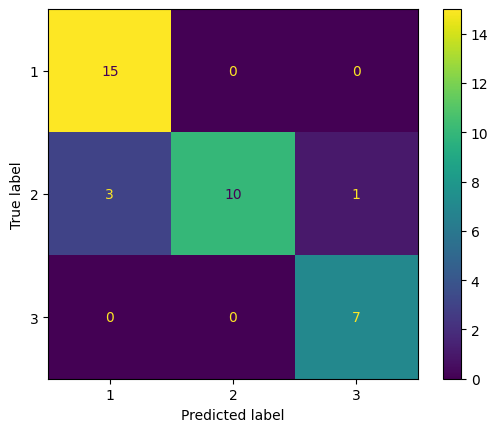

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***SVM for Classification for Linear with parameter tuning***

In [ ]:
#SVM for Classification for Linear
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='linear', random_state=42, max_iter=-1) #default max_itr=-1
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

accuracy_l = round(accuracy_score(y_test, y_pred),2)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[12  0  0]
 [ 2 14  1]
 [ 0  0  7]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.86      1.00      0.92        12
           2       1.00      0.82      0.90        17
           3       0.88      1.00      0.93         7

    accuracy                           0.92        36
   macro avg       0.91      0.94      0.92        36
weighted avg       0.93      0.92      0.92        36



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


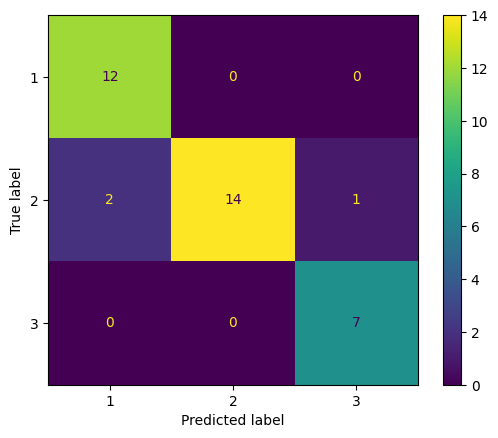

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***Learning Curve for Linear SVM without PCA***

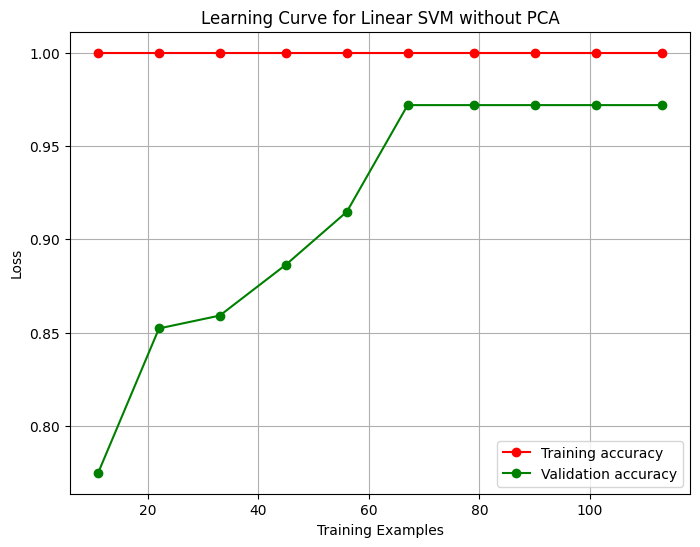

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Example: linear SVM
svc_linear = SVC(kernel='linear', random_state=42, max_iter=-1, C=1.0)

# If you did PCA first
# pca = PCA(n_components=0.95)
# X_train_pca = pca.fit_transform(X_train)
# Instead of X_train, use X_train_pca

train_sizes, train_scores, test_scores = learning_curve(
    estimator=svc_linear,
    X=X_train,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

# Calculate mean and std deviation for scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training accuracy")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Validation accuracy")

# Shaded std bands (optional)
#plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
#plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("Learning Curve for Linear SVM without PCA")
plt.xlabel("Training Examples")
plt.ylabel("Loss")
#plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()


# ***Receiver Operating Characteristic(ROC) curve - Linear SVM***

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


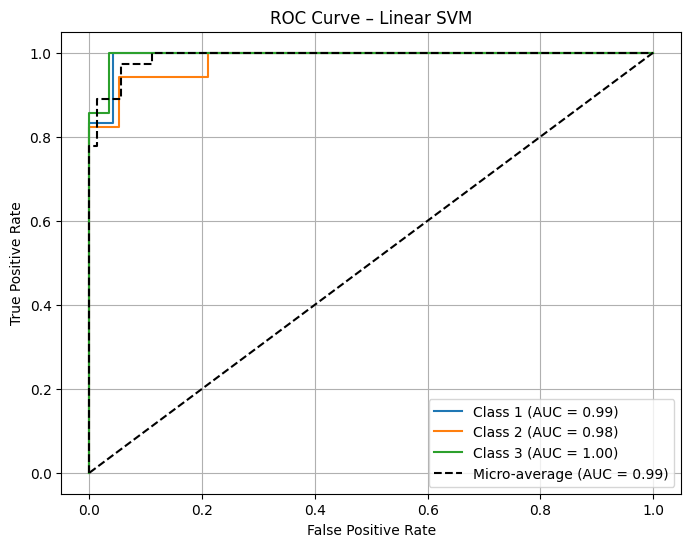

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- Fit the linear SVM with probability estimates ---
svc_linear = SVC(kernel="linear", probability=True, C=1.0, random_state=42)
svc_linear.fit(X_train, y_train)

# --- Predict class probabilities ---
y_score = svc_linear.predict_proba(X_test)

# --- Binarize the true labels ---
# use the same class order as the classifier
y_test_bin = label_binarize(y_test, classes=svc_linear.classes_)
n_classes = y_test_bin.shape[1]

# --- Plot ROC for each class ---
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {svc_linear.classes_[i]} (AUC = {roc_auc:.2f})")

# --- Micro-average ROC ---
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", color="black",
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# --- Plot settings ---
plt.plot([0, 1], [0, 1], 'k--')  # diagonal (chance)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Linear SVM")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ***Area Under The Curve(AUC) - Linear SVM***

In [ ]:
from sklearn.metrics import roc_auc_score

# y_test_bin must be shape (n_samples, n_classes)
# y_score    must be shape (n_samples, n_classes)
# and the columns must correspond to the same class order as your classifier

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print(f"Macro-average AUC: {roc_auc_macro:.3f}")
print(f"Micro-average AUC: {roc_auc_micro:.3f}")


Macro-average AUC: 0.990
Micro-average AUC: 0.991


# ***After PCA(Principal Component Analysis) - SVM Linear***

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- Scale ---
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# --- PCA (reduce to 10 components) ---
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# --- Linear SVM ---
svc_linear = SVC(kernel="linear", C=1.0, random_state=42)   # set probability=True if you want ROC later
svc_linear.fit(X_train_pca, y_train)

# --- Predict & Evaluate ---
y_pred = svc_linear.predict(X_test_pca)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
Confusion matrix:
 [[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]
Classification report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# ***SVM for Classification for Poly***

In [ ]:
#SVM for Classification for Poly
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='poly')
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[ 8  0  4]
 [ 2 14  1]
 [ 0  5  2]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.80      0.67      0.73        12
           2       0.74      0.82      0.78        17
           3       0.29      0.29      0.29         7

    accuracy                           0.67        36
   macro avg       0.61      0.59      0.60        36
weighted avg       0.67      0.67      0.67        36



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


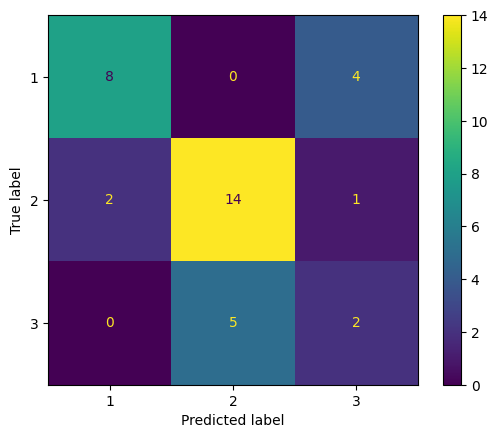

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***SVM for Classification for Poly with parameter tuning***

In [ ]:
#SVM for Classification for Poly
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='poly', degree=3, gamma='auto') #default degree=3 only for poly
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_p = round(accuracy_score(y_test, y_pred),2)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[11  1  0]
 [ 1 18  0]
 [ 0  0  5]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.92      0.92      0.92        12
           2       0.95      0.95      0.95        19
           3       1.00      1.00      1.00         5

    accuracy                           0.94        36
   macro avg       0.95      0.95      0.95        36
weighted avg       0.94      0.94      0.94        36



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


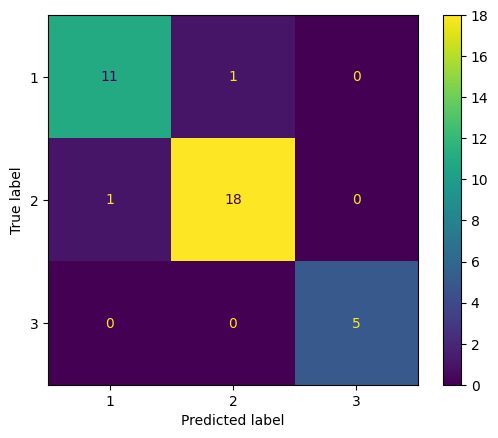

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***Learning Curve for Polynomial SVM without PCA***

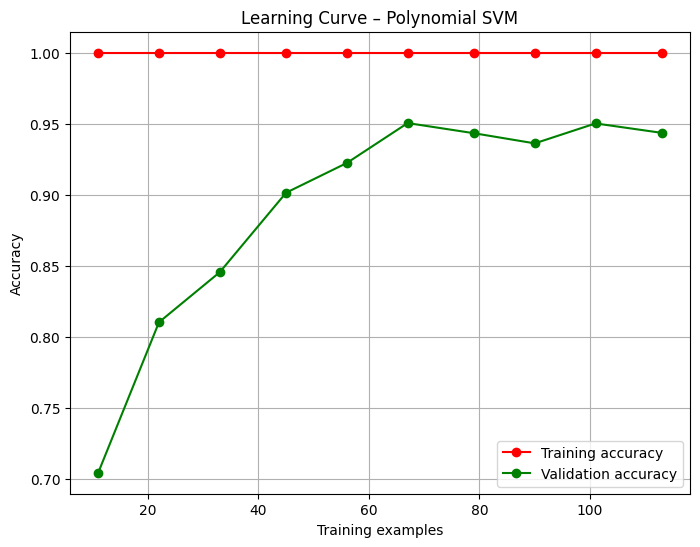

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Example for polynomial SVM
svc_poly = SVC(kernel='poly', degree=3, gamma='auto', C=1.0, random_state=42, max_iter=-1)

train_sizes, train_scores, test_scores = learning_curve(
    estimator=svc_poly,
    X=X_train,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

# mean & std
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

# plot
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training accuracy')
plt.plot(train_sizes, test_mean,  'o-', color='g', label='Validation accuracy')
#plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
#plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.title("Learning Curve – Polynomial SVM")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")           # it's accuracy, not raw loss
plt.legend(loc="best")
plt.grid(True)
plt.show()


# ***Receiver Operating Characteristic(ROC) curve - Polynomial SVM***

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


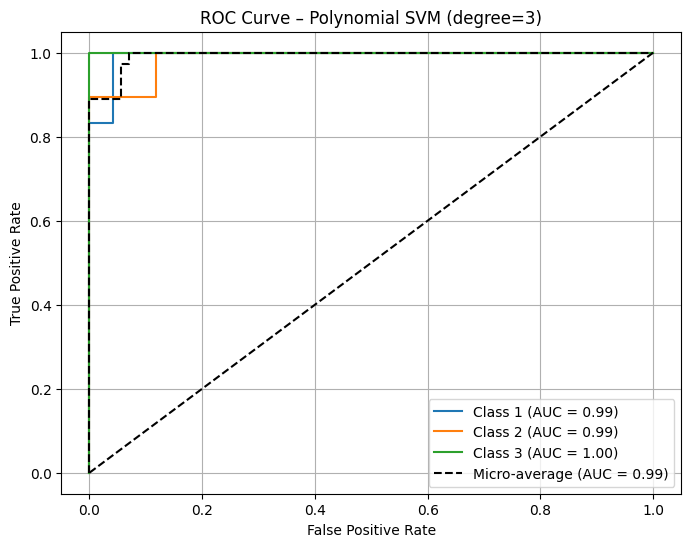

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- Fit the polynomial SVM with probability estimates ---
svc_poly = SVC(
    kernel="poly",       # polynomial kernel
    degree=3,            # cubic (default for poly)
    gamma="auto",        # you can change to 'scale' if you want sklearn's default
    C=1.0,               # regularization strength
    probability=True,    # needed for predict_proba
    random_state=42
)
svc_poly.fit(X_train, y_train)

# --- Predict class probabilities ---
y_score = svc_poly.predict_proba(X_test)

# --- Binarize the true labels using the same class order ---
y_test_bin = label_binarize(y_test, classes=svc_poly.classes_)
n_classes = y_test_bin.shape[1]

# --- Plot ROC for each class ---
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {svc_poly.classes_[i]} (AUC = {roc_auc:.2f})")

# --- Micro-average ROC (all classes together) ---
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", color="black",
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# --- Plot settings ---
plt.plot([0, 1], [0, 1], 'k--')  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Polynomial SVM (degree=3)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ***Area Under The Curve(AUC) - Polynomial SVM***

In [ ]:
from sklearn.metrics import roc_auc_score

# y_test_bin must be shape (n_samples, n_classes)
# y_score    must be shape (n_samples, n_classes)
# and the columns must correspond to the same class order as your classifier

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print(f"Macro-average AUC: {roc_auc_macro:.3f}")
print(f"Micro-average AUC: {roc_auc_micro:.3f}")

Macro-average AUC: 0.994
Micro-average AUC: 0.993


# ***After PCA(Principal Component Analysis) - SVM Polynomial***

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- Scale ---
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# --- PCA (reduce to 10 components) ---
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# --- Polynomial SVM ---
svc_poly = SVC(
    kernel="poly",       # polynomial kernel
    degree=3,            # cubic (default for poly)
    gamma="auto",        # you can change to 'scale' if you want sklearn's default
    C=1.0,               # regularization strength
    probability=True,    # needed for predict_proba
    random_state=42
)
svc_poly.fit(X_train_pca, y_train)

# --- Predict & Evaluate ---
y_pred = svc_poly.predict(X_test_pca)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9722222222222222
Confusion matrix:
 [[13  1  0]
 [ 0 14  0]
 [ 0  0  8]]
Classification report:
               precision    recall  f1-score   support

           1       1.00      0.93      0.96        14
           2       0.93      1.00      0.97        14
           3       1.00      1.00      1.00         8

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# ***SVM for Classification for Gaussian***

In [ ]:
#SVM for Classification for Gaussian
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='rbf')
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[12  0  0]
 [ 2  9  2]
 [ 0  6  5]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.86      1.00      0.92        12
           2       0.60      0.69      0.64        13
           3       0.71      0.45      0.56        11

    accuracy                           0.72        36
   macro avg       0.72      0.72      0.71        36
weighted avg       0.72      0.72      0.71        36



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


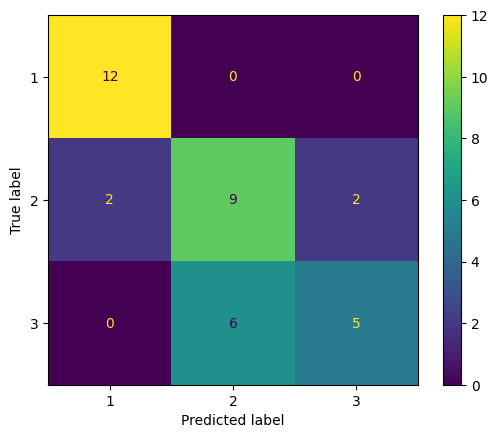

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***SVM for Classification for Gaussian with parameter tuning***

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Define the base classifier with fixed tol and kernel
svc = SVC(kernel='rbf', probability=True)   # add probability=True

# Define parameter grid for tuning
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],                           # Regularization
    'gamma': ['scale', 'auto', 0.01, 0.1],       # Kernel coefficient
    'coef0': [0.0, 0.1, 0.5],                    # Only for 'poly' and 'sigmoid' kernels
    'shrinking': [True, False],                  # Use shrinking heuristic
    'tol': [0.001, 0.0001],                      # Tolerance for stopping
    'max_iter': [-1, 10, 1000],                      # Max iterations (-1 = no limit)
}

# Setup GridSearchCV
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit grid search to training data
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Use best estimator to predict test data
best_classifier = grid_search.best_estimator_
y_pred = best_classifier.predict(X_test)

accuracy_g = round(accuracy_score(y_test, y_pred), 2)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

print(f"Test Accuracy after tuning: {accuracy_g}")


Best parameters found: {'C': 1000, 'coef0': 0.0, 'gamma': 'scale', 'max_iter': -1, 'shrinking': True, 'tol': 0.001}
Best cross-validation accuracy: 0.838423645320197
Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 1  0  7]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00        14
           3       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36

Test Accuracy after tuning: 0.97


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


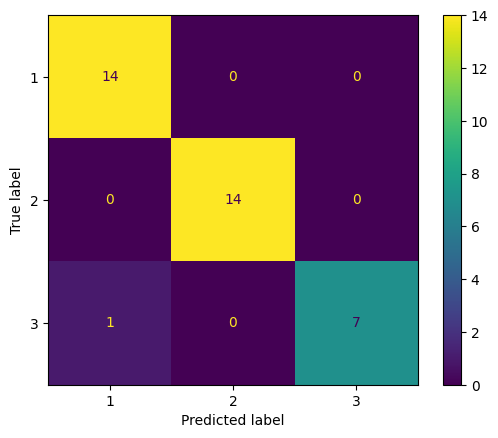

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_classifier, X_test, y_test)

# ***Learning Curve for Gaussian SVM without PCA***

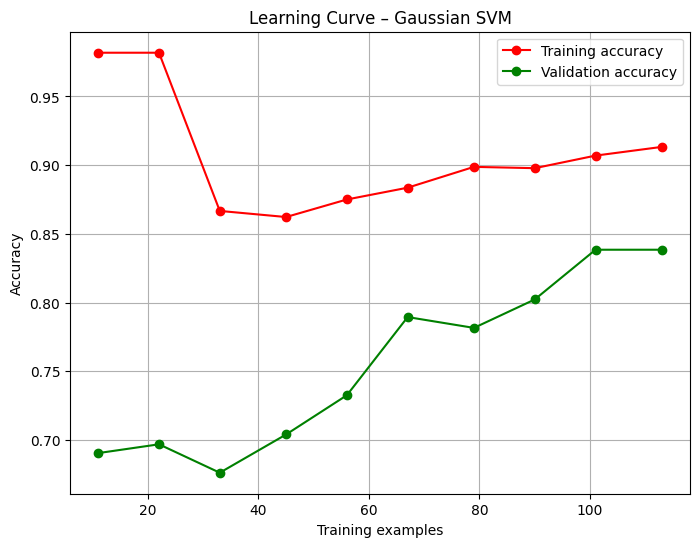

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Example for Gaussian SVM
svc_gaussian = SVC(kernel='rbf', gamma='scale', C=1000, random_state=42, max_iter=-1, shrinking = True, tol = 0.001)

train_sizes, train_scores, test_scores = learning_curve(
    estimator=svc_gaussian,
    X=X_train,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

# mean & std
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

# plot
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training accuracy')
plt.plot(train_sizes, test_mean,  'o-', color='g', label='Validation accuracy')
#plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
#plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.title("Learning Curve – Gaussian SVM")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")           # it's accuracy, not raw loss
plt.legend(loc="best")
plt.grid(True)
plt.show()


# ***Receiver Operating Characteristic(ROC) curve - Gaussian SVM***

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


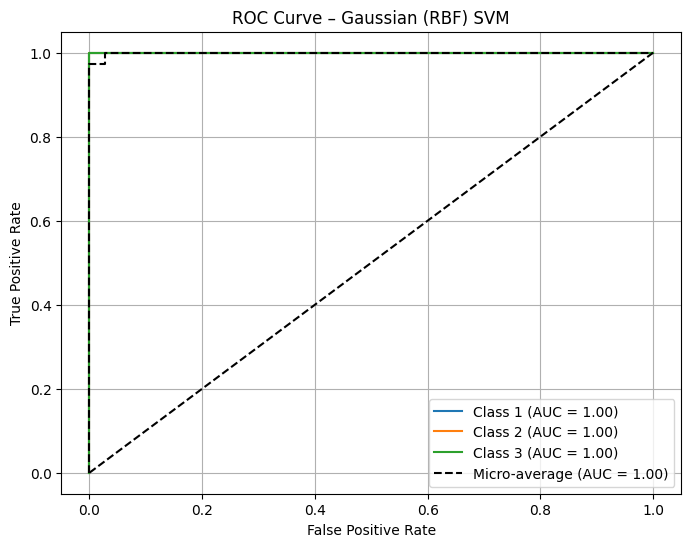

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- Fit the Gaussian (RBF) SVM with probability estimates ---
svc_gaussian = SVC(
    kernel='rbf',
    gamma='scale',     # or 'auto'
    C=1000,            # regularization
    probability=True,  # needed for predict_proba
    random_state=42
)
svc_gaussian.fit(X_train, y_train)

# --- Predict class probabilities ---
y_score = svc_gaussian.predict_proba(X_test)

# --- Binarize the true labels using the same class order ---
y_test_bin = label_binarize(y_test, classes=svc_gaussian.classes_)
n_classes = y_test_bin.shape[1]

# --- Plot ROC for each class ---
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {svc_gaussian.classes_[i]} (AUC = {roc_auc:.2f})")

# --- Micro-average ROC ---
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", color="black",
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# --- Plot settings ---
plt.plot([0, 1], [0, 1], 'k--')  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Gaussian (RBF) SVM")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ***Area Under The Curve(AUC) - Gaussian SVM***

In [ ]:
from sklearn.metrics import roc_auc_score

# y_test_bin must be shape (n_samples, n_classes)
# y_score    must be shape (n_samples, n_classes)
# and the columns must correspond to the same class order as your classifier

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print(f"Macro-average AUC: {roc_auc_macro:.3f}")
print(f"Micro-average AUC: {roc_auc_micro:.3f}")

Macro-average AUC: 1.000
Micro-average AUC: 0.999


# ***After PCA(Principal Component Analysis) - SVM Gaussian***

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- Scale ---
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# --- PCA (reduce to 10 components) ---
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# --- Gaussian SVM ---
svc_gaussian = SVC(
    kernel='rbf',
    gamma='scale',     # or 'auto'
    C=1000,            # regularization
    probability=True,  # needed for predict_proba
    random_state=42
)
svc_gaussian.fit(X_train_pca, y_train)

# --- Predict & Evaluate ---
y_pred = svc_gaussian.predict(X_test_pca)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
Confusion matrix:
 [[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]
Classification report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# ***SVM for Classification for Sigmoid***

In [ ]:
#SVM for Classification for Sigmoid
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='sigmoid')
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[ 3  7  0]
 [11  4  0]
 [11  0  0]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.12      0.30      0.17        10
           2       0.36      0.27      0.31        15
           3       0.00      0.00      0.00        11

    accuracy                           0.19        36
   macro avg       0.16      0.19      0.16        36
weighted avg       0.18      0.19      0.18        36



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning

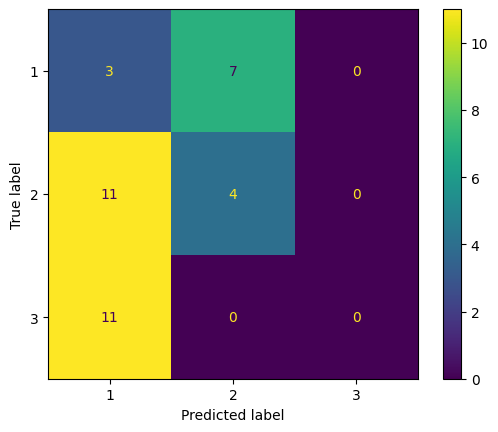

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***SVM for Classification for Sigmoid with parameter tuning***

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize


# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Define the base classifier with fixed tol and kernel
svc = SVC(kernel='sigmoid', probability=True)

# Define parameter grid for tuning
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],                           # Regularization
    'gamma': ['scale', 'auto', 0.1],       # Kernel coefficient
    'coef0': [-1, 0, 1],                    # Only for 'poly' and 'sigmoid' kernels
    'shrinking': [True, False],                  # Use shrinking heuristic
    'tol': [1e-3],                      # Tolerance for stopping
    'max_iter': [-1, 10, 1000],                      # Max iterations (-1 = no limit)
}

# Setup GridSearchCV
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit grid search to training data
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Use best estimator to predict test data
best_classifier = grid_search.best_estimator_
y_pred = best_classifier.predict(X_test)

accuracy_s = round(accuracy_score(y_test, y_pred), 2)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

print(f"Test Accuracy after tuning: {accuracy_s}")


Best parameters found: {'C': 0.1, 'coef0': -1, 'gamma': 'scale', 'max_iter': -1, 'shrinking': True, 'tol': 0.001}
Best cross-validation accuracy: 0.5985221674876847
Confusion Matrix:
[[12  2  0]
 [ 4 10  0]
 [ 4  4  0]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.60      0.86      0.71        14
           2       0.62      0.71      0.67        14
           3       0.00      0.00      0.00         8

    accuracy                           0.61        36
   macro avg       0.41      0.52      0.46        36
weighted avg       0.48      0.61      0.53        36

Test Accuracy after tuning: 0.61


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning

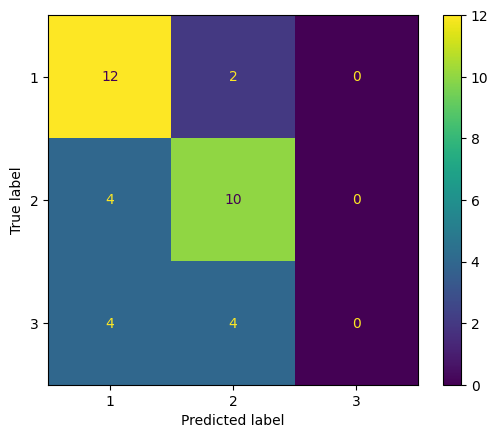

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_classifier, X_test, y_test)

# ***Learning Curve for Sigmoid SVM without PCA***

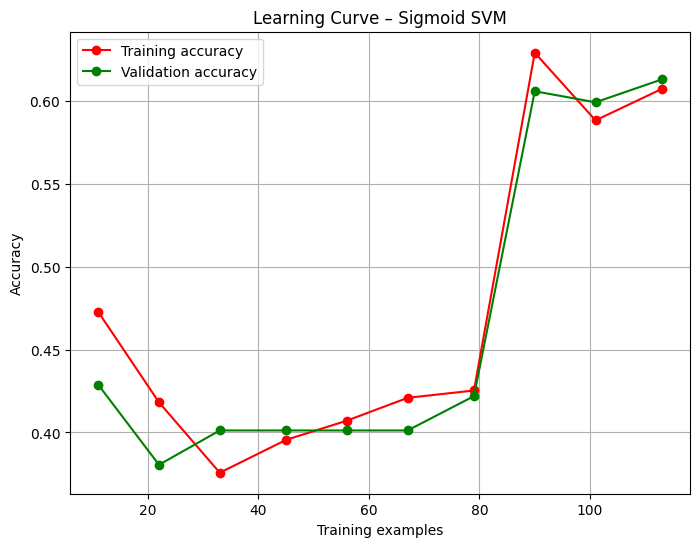

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Example for Gaussian SVM
svc_sigmoid = SVC(
    kernel='sigmoid',
    gamma='scale',     # or 'auto'
    C=0.1,            # regularization
    coef0=-1,
    max_iter=-1,
    shrinking=True,
    tol=0.001,
    probability=True,  # needed for predict_proba
    random_state=42
)
train_sizes, train_scores, test_scores = learning_curve(
    estimator=svc_sigmoid,
    X=X_train,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

# mean & std
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

# plot
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training accuracy')
plt.plot(train_sizes, test_mean,  'o-', color='g', label='Validation accuracy')
#plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
#plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.title("Learning Curve – Sigmoid SVM")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")           # it's accuracy, not raw loss
plt.legend(loc="best")
plt.grid(True)
plt.show()


# ***Receiver Operating Characteristic(ROC) curve - Sigmoid SVM***

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


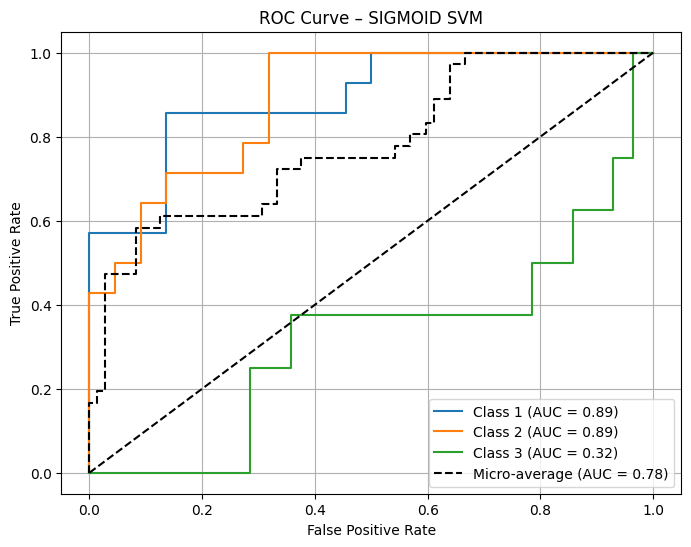

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- Fit the Gaussian (RBF) SVM with probability estimates ---
svc_sigmoid = SVC(
    kernel='sigmoid',
    gamma='scale',     # or 'auto'
    C=0.1,            # regularization
    coef0=-1,
    max_iter=-1,
    shrinking=True,
    tol=0.001,
    probability=True,  # needed for predict_proba
    random_state=42
)
svc_sigmoid.fit(X_train, y_train)

# --- Predict class probabilities ---
y_score = svc_sigmoid.predict_proba(X_test)

# --- Binarize the true labels using the same class order ---
y_test_bin = label_binarize(y_test, classes=svc_sigmoid.classes_)
n_classes = y_test_bin.shape[1]

# --- Plot ROC for each class ---
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {svc_sigmoid.classes_[i]} (AUC = {roc_auc:.2f})")

# --- Micro-average ROC ---
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", color="black",
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# --- Plot settings ---
plt.plot([0, 1], [0, 1], 'k--')  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – SIGMOID SVM")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ***Area Under The Curve(AUC) - Sigmoid SVM***

In [ ]:
from sklearn.metrics import roc_auc_score

# y_test_bin must be shape (n_samples, n_classes)
# y_score    must be shape (n_samples, n_classes)
# and the columns must correspond to the same class order as your classifier

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print(f"Macro-average AUC: {roc_auc_macro:.3f}")
print(f"Micro-average AUC: {roc_auc_micro:.3f}")

Macro-average AUC: 0.700
Micro-average AUC: 0.779


# ***After PCA(Principal Component Analysis) - SVM Sigmoid***

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- Scale ---
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# --- PCA (reduce to 10 components) ---
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# --- Sigmoid SVM ---
svc_sigmoid = SVC(
    kernel='sigmoid',
    gamma='scale',     # or 'auto'
    C=0.1,            # regularization
    coef0=-1,
    max_iter=-1,
    shrinking=True,
    tol=0.001,
    probability=True,  # needed for predict_proba
    random_state=42
)
svc_sigmoid.fit(X_train_pca, y_train)

# --- Predict & Evaluate ---
y_pred = svc_sigmoid.predict(X_test_pca)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9722222222222222
Confusion matrix:
 [[13  1  0]
 [ 0 14  0]
 [ 0  0  8]]
Classification report:
               precision    recall  f1-score   support

           1       1.00      0.93      0.96        14
           2       0.93      1.00      0.97        14
           3       1.00      1.00      1.00         8

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# ***Comparison between classifiers***

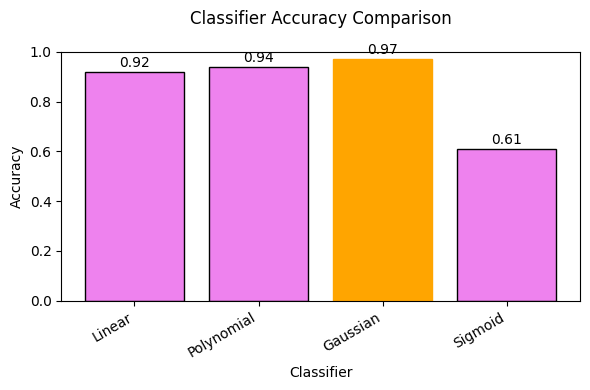

In [ ]:
# Put into DataFrame
df = pd.DataFrame({
    "Result": ["Linear", "Polynomial", "Gaussian", "Sigmoid"],
    "Accuracy": [accuracy_l, accuracy_p, accuracy_g, accuracy_s]
})

# Identify highest accuracy
max_idx = df["Accuracy"].idxmax()

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(df["Result"], df["Accuracy"], color="violet", edgecolor="black")

# Highlight best bar
bars[max_idx].set_color("orange")

# Add text above bars
for i, val in enumerate(df["Accuracy"]):
    plt.text(i, val + 0.02, f"{val:.2f}", ha="center")

plt.title("Classifier Accuracy Comparison", pad=20)
plt.xlabel("Classifier")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.xticks(rotation=30, ha="right")  # rotate labels so no overlap
plt.tight_layout()                   # auto-adjust spacing
plt.show()


# ***Applying different values of train-test set splits (Eg.: 50:50, 60:40, 70:30 and 80:20) in SVM Gaussian***

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Define the base classifier with fixed tol and kernel
svc = SVC(kernel='rbf', probability=True)   # add probability=True

# Define parameter grid for tuning
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],                           # Regularization
    'gamma': ['scale', 'auto', 0.01, 0.1],       # Kernel coefficient
    'coef0': [0.0, 0.1, 0.5],                    # Only for 'poly' and 'sigmoid' kernels
    'shrinking': [True, False],                  # Use shrinking heuristic
    'tol': [0.001, 0.0001],                      # Tolerance for stopping
    'max_iter': [-1, 10, 1000],                      # Max iterations (-1 = no limit)
}

# Setup GridSearchCV
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit grid search to training data
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Use best estimator to predict test data
best_classifier = grid_search.best_estimator_
y_pred = best_classifier.predict(X_test)

accuracy_2 = round(accuracy_score(y_test, y_pred), 2)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

print(f"Test Accuracy after tuning: {accuracy_2}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Define the base classifier with fixed tol and kernel
svc = SVC(kernel='rbf', probability=True)   # add probability=True

# Define parameter grid for tuning
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],                           # Regularization
    'gamma': ['scale', 'auto', 0.01, 0.1],       # Kernel coefficient
    'coef0': [0.0, 0.1, 0.5],                    # Only for 'poly' and 'sigmoid' kernels
    'shrinking': [True, False],                  # Use shrinking heuristic
    'tol': [0.001, 0.0001],                      # Tolerance for stopping
    'max_iter': [-1, 10, 1000],                      # Max iterations (-1 = no limit)
}

# Setup GridSearchCV
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit grid search to training data
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Use best estimator to predict test data
best_classifier = grid_search.best_estimator_
y_pred = best_classifier.predict(X_test)

accuracy_3 = round(accuracy_score(y_test, y_pred), 2)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

print(f"Test Accuracy after tuning: {accuracy_3}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, random_state=42)

# Define the base classifier with fixed tol and kernel
svc = SVC(kernel='rbf', probability=True)   # add probability=True

# Define parameter grid for tuning
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],                           # Regularization
    'gamma': ['scale', 'auto', 0.01, 0.1],       # Kernel coefficient
    'coef0': [0.0, 0.1, 0.5],                    # Only for 'poly' and 'sigmoid' kernels
    'shrinking': [True, False],                  # Use shrinking heuristic
    'tol': [0.001, 0.0001],                      # Tolerance for stopping
    'max_iter': [-1, 10, 1000],                      # Max iterations (-1 = no limit)
}

# Setup GridSearchCV
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit grid search to training data
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Use best estimator to predict test data
best_classifier = grid_search.best_estimator_
y_pred = best_classifier.predict(X_test)

accuracy_4 = round(accuracy_score(y_test, y_pred), 2)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

print(f"Test Accuracy after tuning: {accuracy_4}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.50, random_state=42)

# Define the base classifier with fixed tol and kernel
svc = SVC(kernel='rbf', probability=True)   # add probability=True

# Define parameter grid for tuning
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],                           # Regularization
    'gamma': ['scale', 'auto', 0.01, 0.1],       # Kernel coefficient
    'coef0': [0.0, 0.1, 0.5],                    # Only for 'poly' and 'sigmoid' kernels
    'shrinking': [True, False],                  # Use shrinking heuristic
    'tol': [0.001, 0.0001],                      # Tolerance for stopping
    'max_iter': [-1, 10, 1000],                      # Max iterations (-1 = no limit)
}

# Setup GridSearchCV
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit grid search to training data
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Use best estimator to predict test data
best_classifier = grid_search.best_estimator_
y_pred = best_classifier.predict(X_test)

accuracy_5 = round(accuracy_score(y_test, y_pred), 2)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

print(f"Test Accuracy after tuning: {accuracy_5}")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters found: {'C': 1000, 'coef0': 0.0, 'gamma': 'scale', 'max_iter': -1, 'shrinking': True, 'tol': 0.001}
Best cross-validation accuracy: 0.838423645320197
Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 1  0  7]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00        14
           3       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36

Test Accuracy after tuning: 0.97


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters found: {'C': 1000, 'coef0': 0.0, 'gamma': 'scale', 'max_iter': -1, 'shrinking': True, 'tol': 0.001}
Best cross-validation accuracy: 0.8466666666666667
Confusion Matrix:
[[19  0  0]
 [ 1 20  0]
 [ 1  2 11]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.90      1.00      0.95        19
           2       0.91      0.95      0.93        21
           3       1.00      0.79      0.88        14

    accuracy                           0.93        54
   macro avg       0.94      0.91      0.92        54
weighted avg       0.93      0.93      0.92        54

Test Accuracy after tuning: 0.93


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters found: {'C': 1000, 'coef0': 0.0, 'gamma': 'scale', 'max_iter': -1, 'shrinking': True, 'tol': 0.001}
Best cross-validation accuracy: 0.8294372294372294
Confusion Matrix:
[[26  0  0]
 [ 4 21  2]
 [ 2  4 13]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.81      1.00      0.90        26
           2       0.84      0.78      0.81        27
           3       0.87      0.68      0.76        19

    accuracy                           0.83        72
   macro avg       0.84      0.82      0.82        72
weighted avg       0.84      0.83      0.83        72

Test Accuracy after tuning: 0.83
Best parameters found: {'C': 1000, 'coef0': 0.0, 'gamma': 'scale', 'max_iter': -1, 'shrinking': True, 'tol': 0.001}
Best cross-validation accuracy: 0.7869281045751635
Confusion Matrix:
[[32  0  1]
 [ 4 26  4]
 [ 1  6 15]]
-----------------------------------------------------

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# ***Comparion of train-test split values***

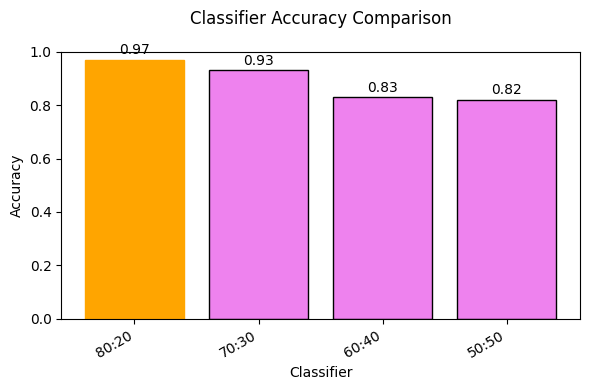

In [ ]:
# Put into DataFrame
df = pd.DataFrame({
    "Result": ["80:20", "70:30", "60:40", "50:50"],
    "Accuracy": [accuracy_2, accuracy_3, accuracy_4, accuracy_5]
})

# Identify highest accuracy
max_idx = df["Accuracy"].idxmax()

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(df["Result"], df["Accuracy"], color="violet", edgecolor="black")

# Highlight best bar
bars[max_idx].set_color("orange")

# Add text above bars
for i, val in enumerate(df["Accuracy"]):
    plt.text(i, val + 0.02, f"{val:.2f}", ha="center")

plt.title("Classifier Accuracy Comparison", pad=20)
plt.xlabel("Classifier")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.xticks(rotation=30, ha="right")  # rotate labels so no overlap
plt.tight_layout()                   # auto-adjust spacing
plt.show()


# ***MLP Classifier without Parameter Tuning***

In [ ]:
# MLP for Classification
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using MLP
from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier() # Instantiate the classifier
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("------------------------------------")
print("------------------------------------")

print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[13  0  0]
 [ 6  6  0]
 [ 9  2  0]]
------------------------------------
------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.46      1.00      0.63        13
           2       0.75      0.50      0.60        12
           3       0.00      0.00      0.00        11

    accuracy                           0.53        36
   macro avg       0.40      0.50      0.41        36
weighted avg       0.42      0.53      0.43        36



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: U

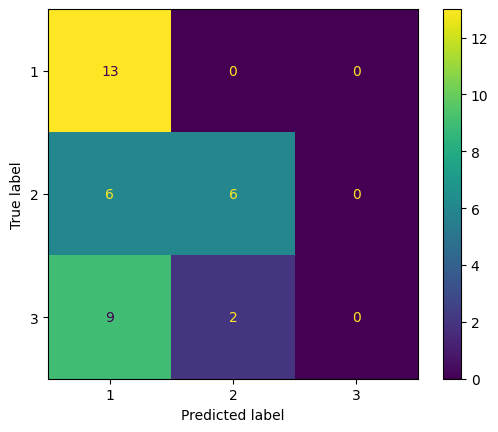

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***MLP Classifier with Momentum Parameter Tuning***

In [ ]:
#MLP for Classification

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using MLP

from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(100, 100, 100), momentum=0.9)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_m1 = round(accuracy_score(y_test, y_pred),2)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("-------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[12  1  0]
 [ 1 15  0]
 [ 0  1  6]]
-------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.92      0.92      0.92        13
           2       0.88      0.94      0.91        16
           3       1.00      0.86      0.92         7

    accuracy                           0.92        36
   macro avg       0.94      0.91      0.92        36
weighted avg       0.92      0.92      0.92        36



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


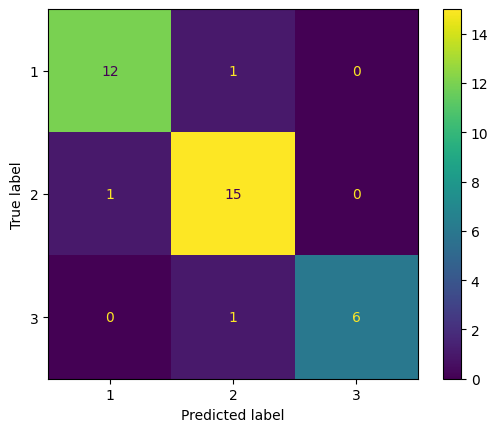

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***Learning Curve and training and loss generation curve - Momemtum MLP***

Lea

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


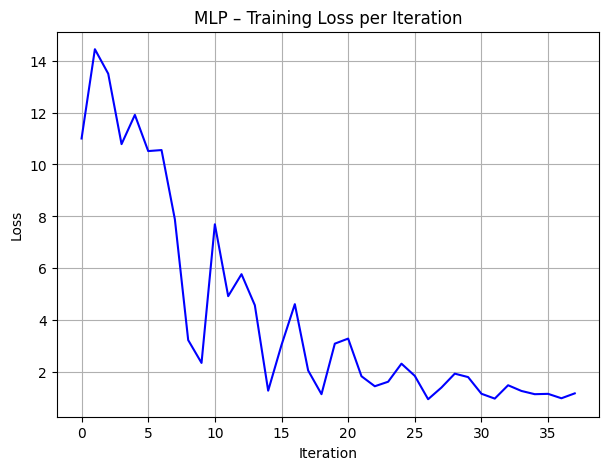

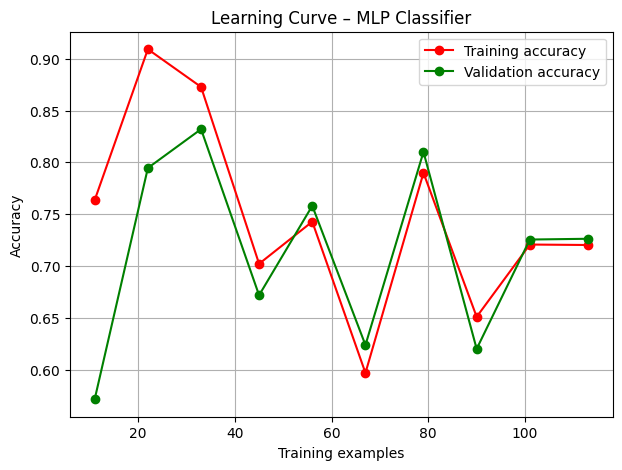

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Fit an MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,100,100),  # tweak if you want
    momentum=0.9
)

mlp.fit(X_train, y_train)

# --- 2. Plot LOSS curve (iterations vs loss) ---
plt.figure(figsize=(7, 5))
plt.plot(mlp.loss_curve_, 'b-')
plt.title("MLP – Training Loss per Iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# --- 3. Learning curve (accuracy vs training size) ---
train_sizes, train_scores, test_scores = learning_curve(
    estimator=mlp,
    X=X_train,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training accuracy')
plt.plot(train_sizes, test_mean,  'o-', color='g', label='Validation accuracy')
# Optional shaded error bands:
# plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
# plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.title("Learning Curve – MLP Classifier")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()


# ***Receiver Operating Characteristic(ROC) curve - Momentum MLP***

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


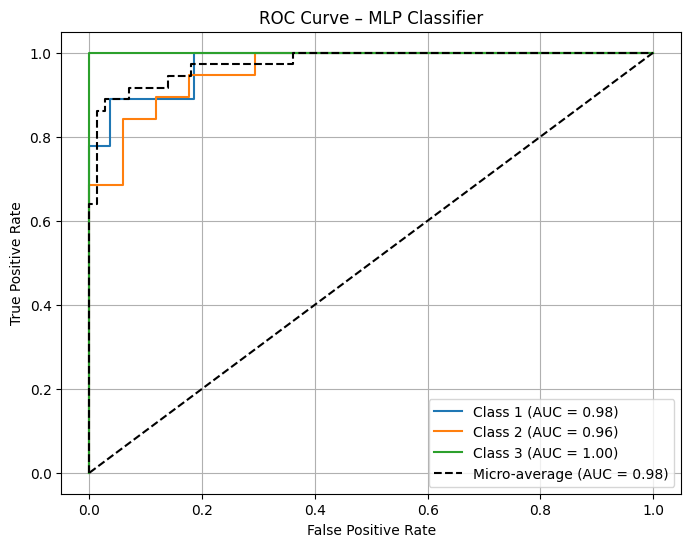

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- 1. Fit MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,100,100),   # change if you want more neurons/layers
    momentum=0.9
)
mlp.fit(X_train, y_train)

# --- 2. Predict class probabilities ---
y_score = mlp.predict_proba(X_test)

# --- 3. Binarize true labels (match the model's class order) ---
y_test_bin = label_binarize(y_test, classes=mlp.classes_)
n_classes = y_test_bin.shape[1]

# --- 4. Plot ROC curve for each class ---
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {mlp.classes_[i]} (AUC = {roc_auc:.2f})")

# --- 5. Micro-average ROC (all classes combined) ---
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", color="black",
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# --- 6. Plot settings ---
plt.plot([0, 1], [0, 1], 'k--')  # diagonal = random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MLP Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ***Area Under The Curve(AUC) - Momentum MLP***

In [ ]:
from sklearn.metrics import roc_auc_score

# y_test_bin must be shape (n_samples, n_classes)
# y_score    must be shape (n_samples, n_classes)
# and the columns must correspond to the same class order as your classifier

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print(f"Macro-average AUC: {roc_auc_macro:.3f}")
print(f"Micro-average AUC: {roc_auc_micro:.3f}")

Macro-average AUC: 0.978
Micro-average AUC: 0.975


# ***After PCA(Principal Component Analysis) - Momentum MLP***

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# --- Scale (MLPs need scaled inputs) ---
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# --- Define MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),   # you can tune (e.g., (64, 32) for two layers)
    momentum=0.9
)

# --- Fit ---
mlp.fit(X_train_scaled, y_train)

# --- Predict & Evaluate ---
y_pred = mlp.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 1.0
Confusion matrix:
 [[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]
Classification report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


# ***MLP Classifier with Epoch size Parameter Tuning***

In [ ]:
#MLP for Classification

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using MLP

from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(100, 100, 100), max_iter=300)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_m2 = round(accuracy_score(y_test, y_pred),2)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("-------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[11  1  0]
 [ 0 14  0]
 [ 0  0 10]]
-------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       1.00      0.92      0.96        12
           2       0.93      1.00      0.97        14
           3       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


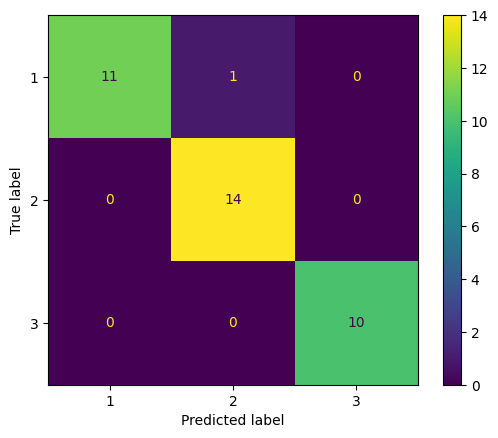

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***Learning Curve and training and loss generation curve - Epoch size MLP***

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


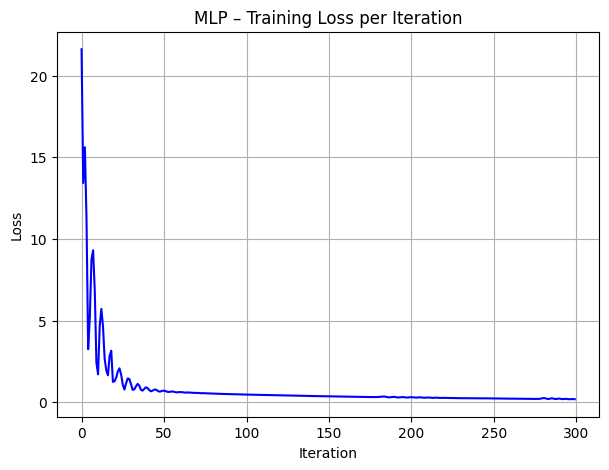

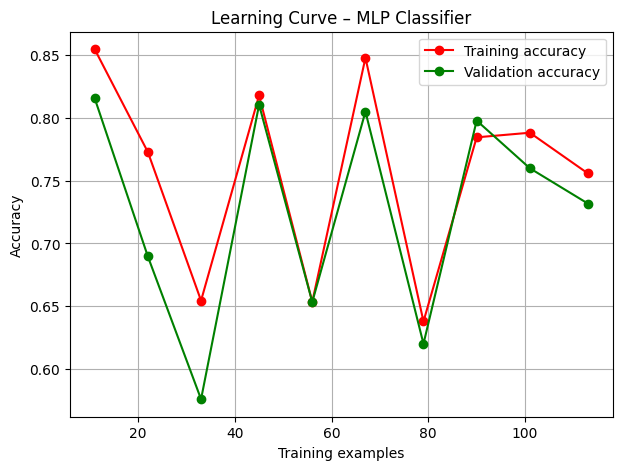

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Fit an MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,100,100),  # tweak if you want
    max_iter=300
)

mlp.fit(X_train, y_train)

# --- 2. Plot LOSS curve (iterations vs loss) ---
plt.figure(figsize=(7, 5))
plt.plot(mlp.loss_curve_, 'b-')
plt.title("MLP – Training Loss per Iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# --- 3. Learning curve (accuracy vs training size) ---
train_sizes, train_scores, test_scores = learning_curve(
    estimator=mlp,
    X=X_train,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training accuracy')
plt.plot(train_sizes, test_mean,  'o-', color='g', label='Validation accuracy')
# Optional shaded error bands:
# plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
# plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.title("Learning Curve – MLP Classifier")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()


# ***Receiver Operating Characteristic(ROC) curve - Epoch size MLP***

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


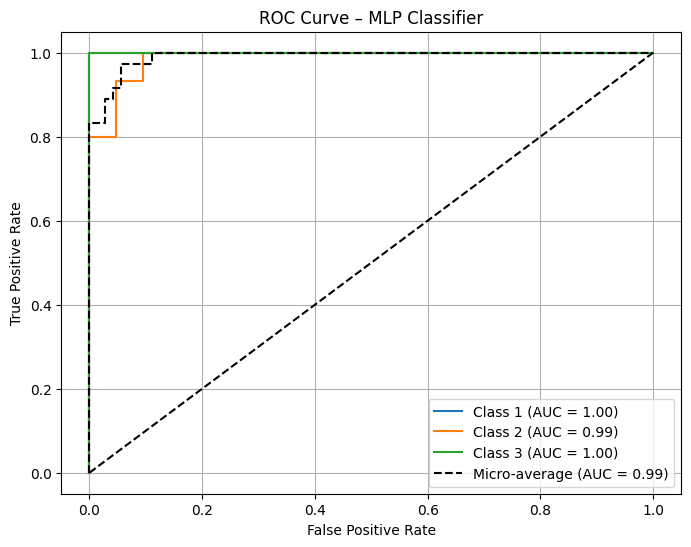

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- 1. Fit MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,100,100),   # change if you want more neurons/layers
    max_iter=300
)
mlp.fit(X_train, y_train)

# --- 2. Predict class probabilities ---
y_score = mlp.predict_proba(X_test)

# --- 3. Binarize true labels (match the model's class order) ---
y_test_bin = label_binarize(y_test, classes=mlp.classes_)
n_classes = y_test_bin.shape[1]

# --- 4. Plot ROC curve for each class ---
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {mlp.classes_[i]} (AUC = {roc_auc:.2f})")

# --- 5. Micro-average ROC (all classes combined) ---
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", color="black",
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# --- 6. Plot settings ---
plt.plot([0, 1], [0, 1], 'k--')  # diagonal = random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MLP Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ***Area Under The Curve(AUC) - Epoch size MLP***

In [ ]:
from sklearn.metrics import roc_auc_score

# y_test_bin must be shape (n_samples, n_classes)
# y_score    must be shape (n_samples, n_classes)
# and the columns must correspond to the same class order as your classifier

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print(f"Macro-average AUC: {roc_auc_macro:.3f}")
print(f"Micro-average AUC: {roc_auc_micro:.3f}")

Macro-average AUC: 0.996
Micro-average AUC: 0.991


# ***After PCA(Principal Component Analysis) - Momentum MLP***

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# --- Scale (MLPs need scaled inputs) ---
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# --- Define MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),   # you can tune (e.g., (64, 32) for two layers)
    max_iter=300
)

# --- Fit ---
mlp.fit(X_train_scaled, y_train)

# --- Predict & Evaluate ---
y_pred = mlp.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 1.0
Confusion matrix:
 [[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]
Classification report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



# ***MLP Classifier with Learning Rate Parameter Tuning***

In [ ]:
#MLP for Classification

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using MLP

from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(100, 100, 100), learning_rate_init=0.01)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_m3 = round(accuracy_score(y_test, y_pred),2)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("-------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[ 6  1  0]
 [ 1 15  0]
 [ 0  0 13]]
-------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.86      0.86      0.86         7
           2       0.94      0.94      0.94        16
           3       1.00      1.00      1.00        13

    accuracy                           0.94        36
   macro avg       0.93      0.93      0.93        36
weighted avg       0.94      0.94      0.94        36



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


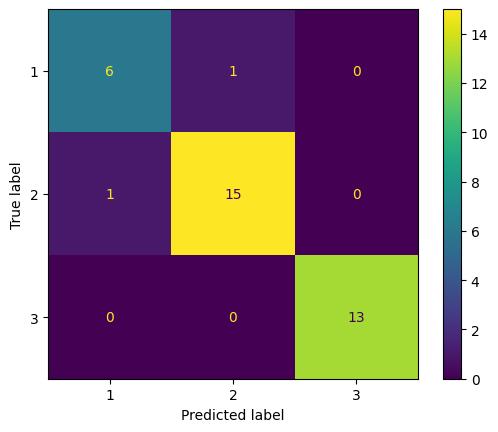

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***Learning Curve and training and loss generation curve - Learning rate MLP***

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


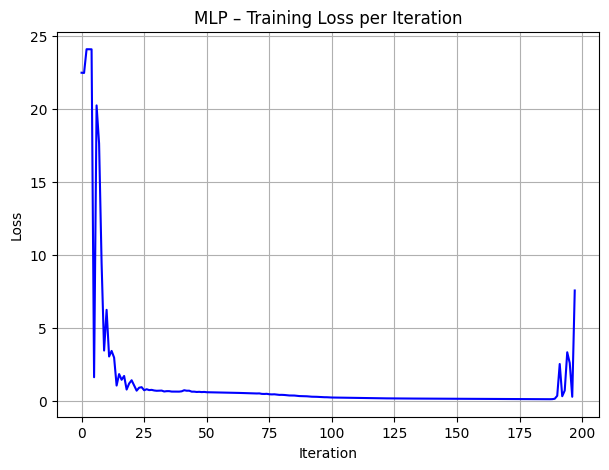

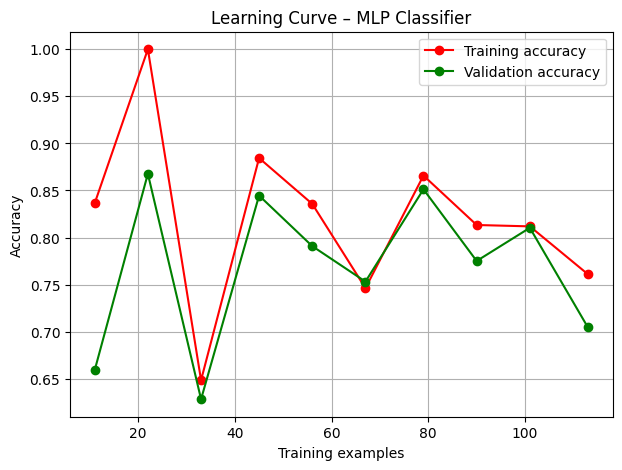

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Fit an MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,100,100),  # tweak if you want
    learning_rate_init=0.01
)

mlp.fit(X_train, y_train)

# --- 2. Plot LOSS curve (iterations vs loss) ---
plt.figure(figsize=(7, 5))
plt.plot(mlp.loss_curve_, 'b-')
plt.title("MLP – Training Loss per Iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# --- 3. Learning curve (accuracy vs training size) ---
train_sizes, train_scores, test_scores = learning_curve(
    estimator=mlp,
    X=X_train,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training accuracy')
plt.plot(train_sizes, test_mean,  'o-', color='g', label='Validation accuracy')
# Optional shaded error bands:
# plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
# plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.title("Learning Curve – MLP Classifier")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()


# ***Receiver Operating Characteristic(ROC) curve - Learning rate MLP***

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


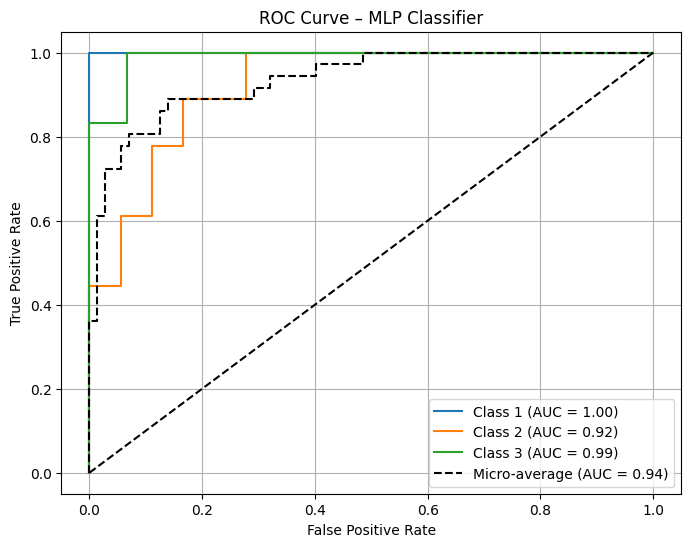

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- 1. Fit MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,100,100),   # change if you want more neurons/layers
    learning_rate_init=0.01
)
mlp.fit(X_train, y_train)

# --- 2. Predict class probabilities ---
y_score = mlp.predict_proba(X_test)

# --- 3. Binarize true labels (match the model's class order) ---
y_test_bin = label_binarize(y_test, classes=mlp.classes_)
n_classes = y_test_bin.shape[1]

# --- 4. Plot ROC curve for each class ---
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {mlp.classes_[i]} (AUC = {roc_auc:.2f})")

# --- 5. Micro-average ROC (all classes combined) ---
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", color="black",
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# --- 6. Plot settings ---
plt.plot([0, 1], [0, 1], 'k--')  # diagonal = random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MLP Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ***Area Under The Curve(AUC) - Learning rate MLP***

In [ ]:
from sklearn.metrics import roc_auc_score

# y_test_bin must be shape (n_samples, n_classes)
# y_score    must be shape (n_samples, n_classes)
# and the columns must correspond to the same class order as your classifier

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print(f"Macro-average AUC: {roc_auc_macro:.3f}")
print(f"Micro-average AUC: {roc_auc_micro:.3f}")

Macro-average AUC: 0.971
Micro-average AUC: 0.936


# ***After PCA(Principal Component Analysis) - Learning rate MLP***

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# --- Scale (MLPs need scaled inputs) ---
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# --- Define MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),   # you can tune (e.g., (64, 32) for two layers)
    learning_rate_init=0.01
)

# --- Fit ---
mlp.fit(X_train_scaled, y_train)

# --- Predict & Evaluate ---
y_pred = mlp.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
Confusion matrix:
 [[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]
Classification report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# ***Comparison of MLP Parameters***

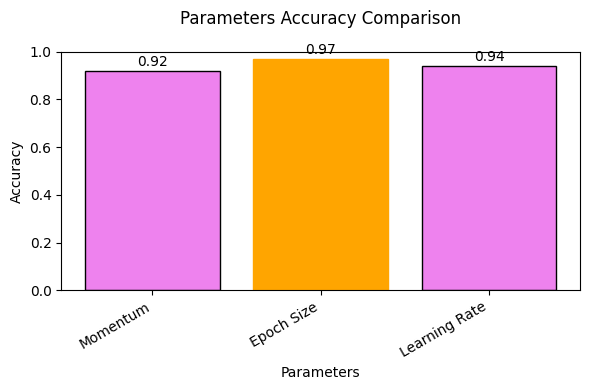

In [ ]:
# Put into DataFrame
df = pd.DataFrame({
    "Result": ["Momentum", "Epoch Size", "Learning Rate"],
    "Accuracy": [accuracy_m1, accuracy_m2, accuracy_m3]
})

# Identify highest accuracy
max_idx = df["Accuracy"].idxmax()

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(df["Result"], df["Accuracy"], color="violet", edgecolor="black")

# Highlight best bar
bars[max_idx].set_color("orange")

# Add text above bars
for i, val in enumerate(df["Accuracy"]):
    plt.text(i, val + 0.02, f"{val:.2f}", ha="center")

plt.title("Parameters Accuracy Comparison", pad=20)
plt.xlabel("Parameters")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.xticks(rotation=30, ha="right")  # rotate labels so no overlap
plt.tight_layout()                   # auto-adjust spacing
plt.show()


# ***MLP Classifier with Epoch Size in different test-train split values***

In [ ]:
#MLP for Classification

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using MLP

from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(100, 100, 100), max_iter=300)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_mn1 = round(accuracy_score(y_test, y_pred),2)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("-------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

#MLP for Classification

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

# Classification using MLP

from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(100, 100, 100), max_iter=300)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_mn2 = round(accuracy_score(y_test, y_pred),2)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("-------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

#MLP for Classification

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40)

# Classification using MLP

from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(100, 100, 100), max_iter=300)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_mn3 = round(accuracy_score(y_test, y_pred),2)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("-------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

#MLP for Classification

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.50)

# Classification using MLP

from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(100, 100, 100), max_iter=300)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_mn4 = round(accuracy_score(y_test, y_pred),2)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("-------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[11  0  0]
 [ 0 16  0]
 [ 0  0  9]]
-------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00         9

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[16  1  0]
 [ 3 18  0]
 [ 0  1 15]]
-------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.84      0.94      0.89        17
           2       0.90      0.86      0.88        21
           3       1.00      0.94      0.97        16

    accuracy                           0.91        54
   macro avg       0.91      0.91      0.91        54
weighted avg       0.91      0.91      0.91        54



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[21  4  0]
 [ 1 25  0]
 [ 3  3 15]]
-------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.84      0.84      0.84        25
           2       0.78      0.96      0.86        26
           3       1.00      0.71      0.83        21

    accuracy                           0.85        72
   macro avg       0.87      0.84      0.85        72
weighted avg       0.87      0.85      0.85        72

Confusion Matrix:
[[28  3  0]
 [ 2 33  1]
 [ 0  3 19]]
-------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       0.93      0.90      0.92        31
           2       0.85      0.92      0.88        36
           3       0.95      0.86      0.90        22

    accuracy                           0.90        89
   macro avg       0.91      0.89      0.90        89
weighted avg       0.90

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


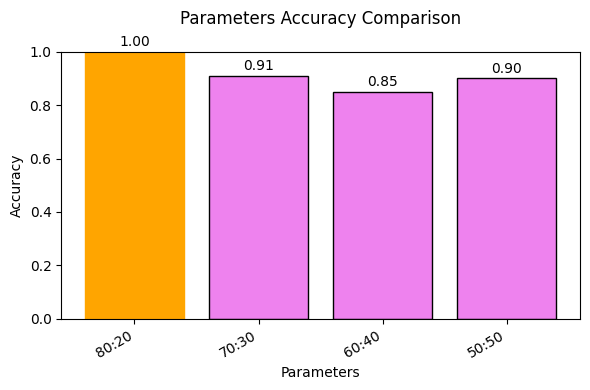

In [ ]:
# Put into DataFrame
df = pd.DataFrame({
    "Result": ["80:20", "70:30", "60:40", "50:50"],
    "Accuracy": [accuracy_mn1, accuracy_mn2, accuracy_mn3, accuracy_mn4]
})

# Identify highest accuracy
max_idx = df["Accuracy"].idxmax()

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(df["Result"], df["Accuracy"], color="violet", edgecolor="black")

# Highlight best bar
bars[max_idx].set_color("orange")

# Add text above bars
for i, val in enumerate(df["Accuracy"]):
    plt.text(i, val + 0.02, f"{val:.2f}", ha="center")

plt.title("Parameters Accuracy Comparison", pad=20)
plt.xlabel("Parameters")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.xticks(rotation=30, ha="right")  # rotate labels so no overlap
plt.tight_layout()                   # auto-adjust spacing
plt.show()


# ***Random Forest Classifier with Parametr Tuning***

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20,random_state=0)

# Feature Scaling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Classification
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42)
classifier.fit(X_train,y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("--------------------------------------------------")
print("--------------------------------------------------")

print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

print("--------------------------------------------------")
print("--------------------------------------------------")

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Confusion Matrix:
[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]
--------------------------------------------------
--------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00         6

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

--------------------------------------------------
--------------------------------------------------
Accuracy:
1.0


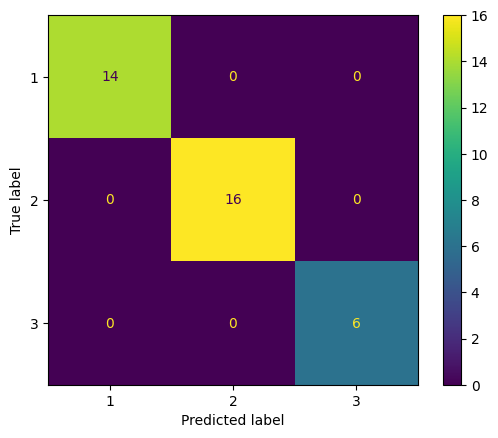

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***Learning Curve for Random Forest***

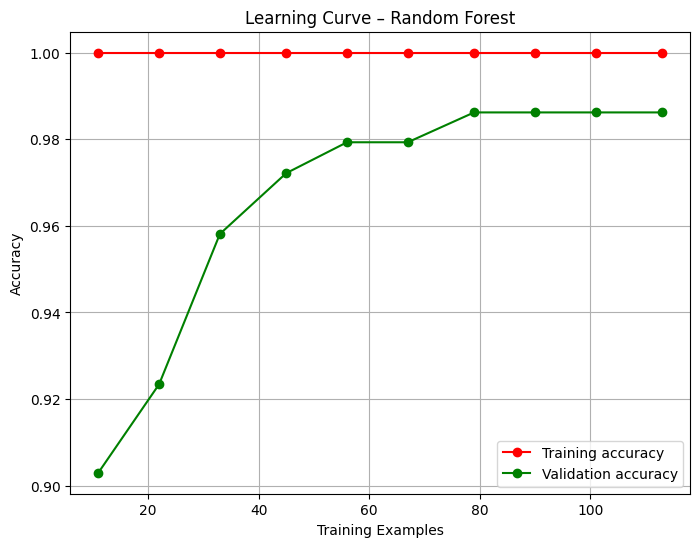

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# --- Random Forest Classifier ---
rf_clf = RandomForestClassifier(n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42)

# --- Learning curve ---
train_sizes, train_scores, test_scores = learning_curve(
    estimator=rf_clf,
    X=X_train,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

# --- Mean & Std ---
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training accuracy")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Validation accuracy")

# Optional shading for std
# plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
# plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("Learning Curve – Random Forest")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")   # Accuracy is correct metric here (not raw loss)
plt.legend(loc="best")
plt.grid(True)
plt.show()


# ***Receiver Operating Characteristic(ROC) curve - Random Forest***

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


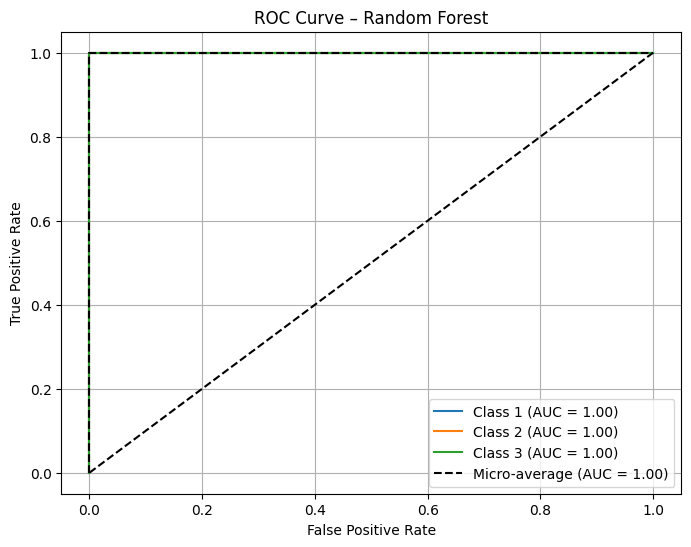

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- Fit the Random Forest with probability estimates ---
rf_clf = RandomForestClassifier(n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42)
rf_clf.fit(X_train, y_train)

# --- Predict class probabilities ---
y_score = rf_clf.predict_proba(X_test)

# --- Binarize the true labels ---
# use the same class order as the classifier
y_test_bin = label_binarize(y_test, classes=rf_clf.classes_)
n_classes = y_test_bin.shape[1]

# --- Plot ROC for each class ---
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {rf_clf.classes_[i]} (AUC = {roc_auc:.2f})")

# --- Micro-average ROC ---
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", color="black",
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# --- Plot settings ---
plt.plot([0, 1], [0, 1], 'k--')  # diagonal (chance)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ***Area Under The Curve(AUC) - Random Forest***

In [ ]:
from sklearn.metrics import roc_auc_score

# y_test_bin must be shape (n_samples, n_classes)
# y_score    must be shape (n_samples, n_classes)
# and the columns must correspond to the same class order as your classifier

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print(f"Macro-average AUC: {roc_auc_macro:.3f}")
print(f"Micro-average AUC: {roc_auc_micro:.3f}")


Macro-average AUC: 1.000
Micro-average AUC: 1.000


# ***After PCA(Principal Component Analysis) - Random Forest***

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- Scale ---
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# --- PCA (reduce to 10 components) ---
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# --- Random Forest ---
rf_clf = RandomForestClassifier(n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42)
rf_clf.fit(X_train_pca, y_train)

# --- Predict & Evaluate ---
y_pred = rf_clf.predict(X_test_pca)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 1.0
Confusion matrix:
 [[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]
Classification report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



# ***Handwritten Digit Dataset***

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
optical_recognition_of_handwritten_digits = fetch_ucirepo(id=80)

# data (as pandas dataframes)
X = optical_recognition_of_handwritten_digits.data.features
y = optical_recognition_of_handwritten_digits.data.targets

# metadata
#print(optical_recognition_of_handwritten_digits.metadata)

# variable information
#print(optical_recognition_of_handwritten_digits.variables)


# ***SVM for Classification for Linear***

In [ ]:
#SVM for Classification for Linear
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[115   0   0   0   0   0   0   0   0   0]
 [  0 106   0   0   0   0   0   0   1   2]
 [  0   0 111   0   0   0   1   0   0   0]
 [  0   0   0 105   0   0   0   0   0   0]
 [  0   0   0   0 101   0   0   0   1   0]
 [  0   1   0   2   0 111   0   0   0   1]
 [  0   0   0   0   1   0 109   0   0   0]
 [  0   0   0   0   0   0   0 119   0   0]
 [  0   3   0   0   1   0   0   0 107   1]
 [  0   0   0   1   2   1   0   0   1 120]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       115
           1       0.96      0.97      0.97       109
           2       1.00      0.99      1.00       112
           3       0.97      1.00      0.99       105
           4       0.96      0.99      0.98       102
           5       0.99      0.97      0.98       115
           6       0.99      0.99      0.99       110
           7       1.00      

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


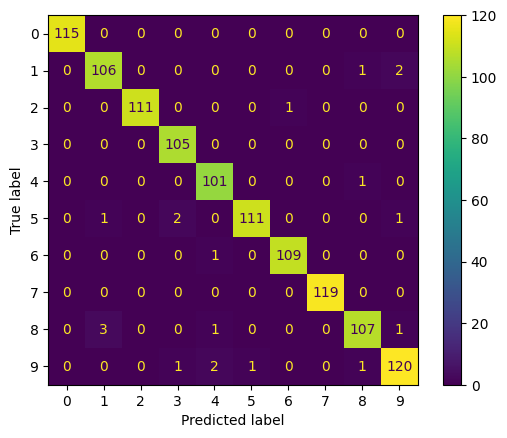

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***SVM for Classification for Linear with parameter tuning***

In [ ]:
#SVM for Classification for Linear
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='linear', random_state=42, max_iter=-1) #default max_itr=-1
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

accuracy_h1 = round(accuracy_score(y_test, y_pred),2)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[120   0   0   0   0   0   0   0   0   0]
 [  0 111   0   0   0   0   0   0   3   0]
 [  0   0  97   0   0   0   1   0   0   0]
 [  0   0   0 109   0   2   0   0   0   2]
 [  0   0   0   0 114   0   0   0   0   0]
 [  0   0   0   2   0 116   0   0   1   0]
 [  0   0   0   0   1   0 117   0   0   0]
 [  0   0   0   0   2   0   0 100   0   1]
 [  0   4   0   0   0   1   0   0 102   0]
 [  0   2   0   3   1   1   0   0   1 110]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       0.95      0.97      0.96       114
           2       1.00      0.99      0.99        98
           3       0.96      0.96      0.96       113
           4       0.97      1.00      0.98       114
           5       0.97      0.97      0.97       119
           6       0.99      0.99      0.99       118
           7       1.00      

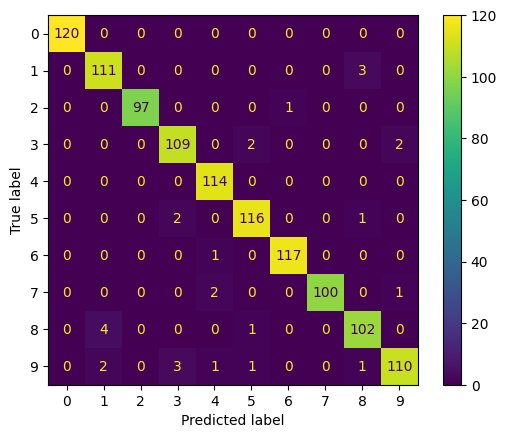

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***Learning Curve for Linear SVM without PCA***

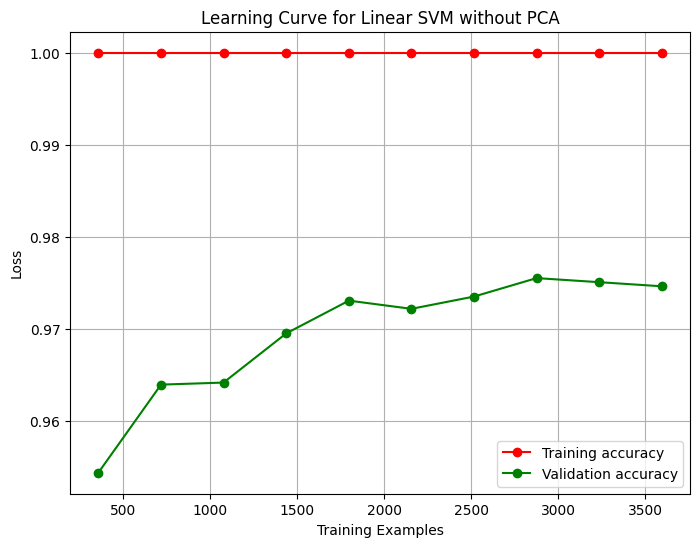

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Example: linear SVM
svc_linear = SVC(kernel='linear', random_state=42, max_iter=-1, C=1.0)

# If you did PCA first
# pca = PCA(n_components=0.95)
# X_train_pca = pca.fit_transform(X_train)
# Instead of X_train, use X_train_pca

train_sizes, train_scores, test_scores = learning_curve(
    estimator=svc_linear,
    X=X_train,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

# Calculate mean and std deviation for scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training accuracy")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Validation accuracy")

# Shaded std bands (optional)
#plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
#plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("Learning Curve for Linear SVM without PCA")
plt.xlabel("Training Examples")
plt.ylabel("Loss")
#plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()


# ***Receiver Operating Characteristic(ROC) curve - Linear SVM***

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


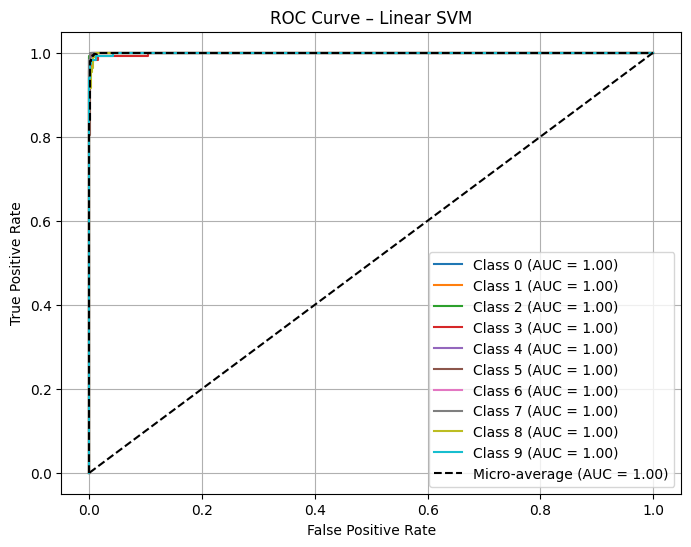

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- Fit the linear SVM with probability estimates ---
svc_linear = SVC(kernel="linear", probability=True, C=1.0, random_state=42)
svc_linear.fit(X_train, y_train)

# --- Predict class probabilities ---
y_score = svc_linear.predict_proba(X_test)

# --- Binarize the true labels ---
# use the same class order as the classifier
y_test_bin = label_binarize(y_test, classes=svc_linear.classes_)
n_classes = y_test_bin.shape[1]

# --- Plot ROC for each class ---
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {svc_linear.classes_[i]} (AUC = {roc_auc:.2f})")

# --- Micro-average ROC ---
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", color="black",
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# --- Plot settings ---
plt.plot([0, 1], [0, 1], 'k--')  # diagonal (chance)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Linear SVM")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ***Area Under The Curve(AUC) - Linear SVM***

In [ ]:
from sklearn.metrics import roc_auc_score

# y_test_bin must be shape (n_samples, n_classes)
# y_score    must be shape (n_samples, n_classes)
# and the columns must correspond to the same class order as your classifier

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print(f"Macro-average AUC: {roc_auc_macro:.3f}")
print(f"Micro-average AUC: {roc_auc_micro:.3f}")


Macro-average AUC: 1.000
Micro-average AUC: 1.000


# ***After PCA(Principal Component Analysis) - SVM Linear***

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- Scale ---
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# --- PCA (reduce to 10 components) ---
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# --- Linear SVM ---
svc_linear = SVC(kernel="linear", C=1.0, random_state=42)   # set probability=True if you want ROC later
svc_linear.fit(X_train_pca, y_train)

# --- Predict & Evaluate ---
y_pred = svc_linear.predict(X_test_pca)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.9110320284697508
Confusion matrix:
 [[106   0   0   0   1   1   0   0   0   0]
 [  0  96   0   1   0   0   1   0   3   1]
 [  0   1 103   0   1   0   0   0   1   1]
 [  0   0   0  99   0   3   0   1   4  11]
 [  1   2   0   0 109   0   1   2   1   1]
 [  0   1   1   1   1  82   0   0   3   8]
 [  1   1   0   0   1   0 120   0   0   0]
 [  0   1   0   0   2   0   0 120   1   0]
 [  0   6   1   2   3   1   0   0  88   4]
 [  0   2   1   9   1   5   0   1   3 101]]
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       108
           1       0.87      0.94      0.91       102
           2       0.97      0.96      0.97       107
           3       0.88      0.84      0.86       118
           4       0.92      0.93      0.92       117
           5       0.89      0.85      0.87        97
           6       0.98      0.98      0.98       123
           7       0.97      0.97      0.97       124
          

# ***SVM for Classification for Poly without Parameter Tuning***

In [ ]:
#SVM for Classification for Poly
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='poly')
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[121   0   0   0   0   0   0   0   0   0]
 [  0  99   0   0   0   0   0   0   0   1]
 [  0   0 120   0   0   0   0   0   0   0]
 [  0   0   0 113   0   0   0   0   0   0]
 [  0   0   0   0 106   0   0   0   0   0]
 [  0   0   0   1   0 119   0   0   1   0]
 [  0   0   0   0   1   0 100   0   0   0]
 [  0   0   0   0   0   0   0 131   0   0]
 [  0   0   0   0   0   0   0   0 113   1]
 [  0   1   0   2   0   0   0   0   0  94]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       121
           1       0.99      0.99      0.99       100
           2       1.00      1.00      1.00       120
           3       0.97      1.00      0.99       113
           4       0.99      1.00      1.00       106
           5       1.00      0.98      0.99       121
           6       1.00      0.99      1.00       101
           7       1.00      

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


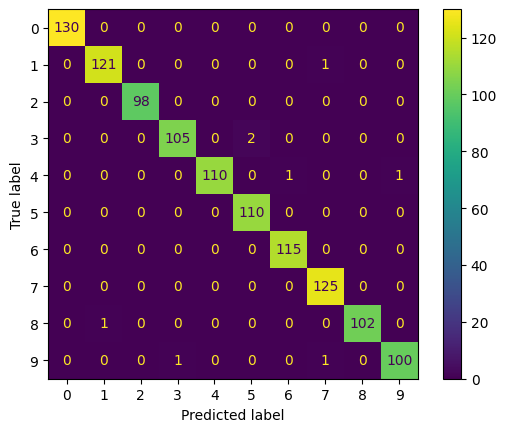

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***SVM for Classification for Poly with parameter tuning***

In [ ]:
#SVM for Classification for Poly
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='poly', degree=3, gamma='auto') #default degree=3 only for poly
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_h2 = round(accuracy_score(y_test, y_pred),2)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[123   0   0   0   0   0   1   0   0   0]
 [  0 108   0   0   0   0   0   0   0   0]
 [  0   0 115   0   0   0   0   0   0   1]
 [  0   0   2  92   0   1   0   0   0   1]
 [  0   0   0   0 107   0   0   0   0   0]
 [  0   0   0   0   0 114   0   0   0   1]
 [  0   0   1   0   0   0 117   0   0   0]
 [  0   0   0   0   0   0   0 129   0   0]
 [  0   1   0   1   0   0   0   0 110   0]
 [  1   0   0   1   1   0   0   0   0  96]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       124
           1       0.99      1.00      1.00       108
           2       0.97      0.99      0.98       116
           3       0.98      0.96      0.97        96
           4       0.99      1.00      1.00       107
           5       0.99      0.99      0.99       115
           6       0.99      0.99      0.99       118
           7       1.00      

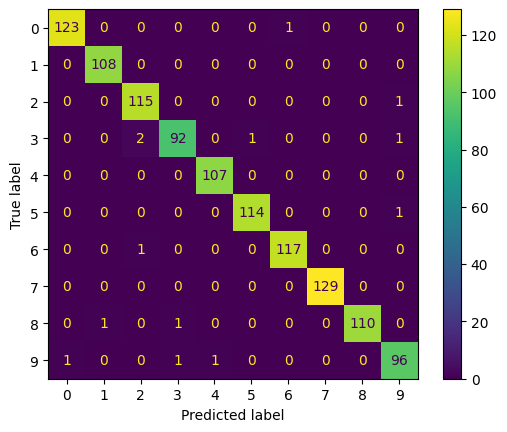

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***Learning Curve for Polynomial SVM without PCA***

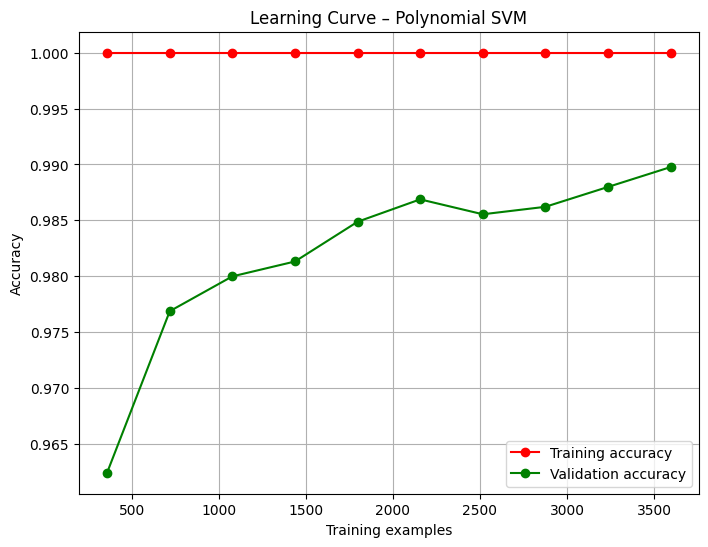

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Example for polynomial SVM
svc_poly = SVC(kernel='poly', degree=3, gamma='auto', C=1.0, random_state=42, max_iter=-1)

train_sizes, train_scores, test_scores = learning_curve(
    estimator=svc_poly,
    X=X_train,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

# mean & std
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

# plot
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training accuracy')
plt.plot(train_sizes, test_mean,  'o-', color='g', label='Validation accuracy')
#plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
#plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.title("Learning Curve – Polynomial SVM")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")           # it's accuracy, not raw loss
plt.legend(loc="best")
plt.grid(True)
plt.show()


# ***Receiver Operating Characteristic(ROC) curve - Polynomial SVM***

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


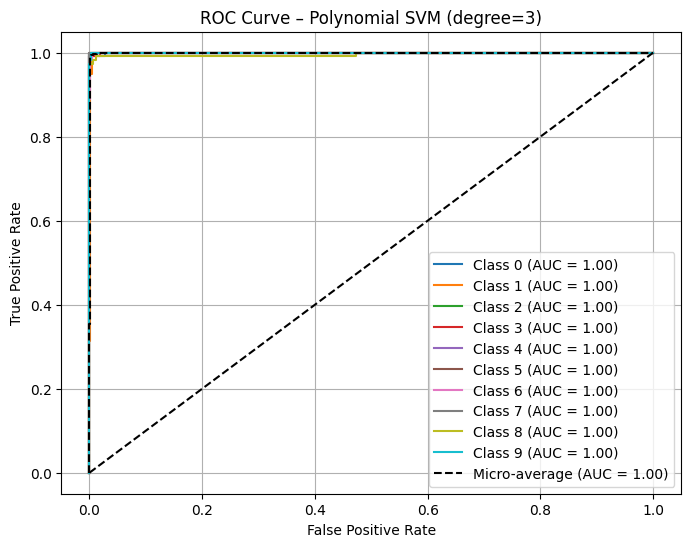

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- Fit the polynomial SVM with probability estimates ---
svc_poly = SVC(
    kernel="poly",       # polynomial kernel
    degree=3,            # cubic (default for poly)
    gamma="auto",        # you can change to 'scale' if you want sklearn's default
    C=1.0,               # regularization strength
    probability=True,    # needed for predict_proba
    random_state=42
)
svc_poly.fit(X_train, y_train)

# --- Predict class probabilities ---
y_score = svc_poly.predict_proba(X_test)

# --- Binarize the true labels using the same class order ---
y_test_bin = label_binarize(y_test, classes=svc_poly.classes_)
n_classes = y_test_bin.shape[1]

# --- Plot ROC for each class ---
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {svc_poly.classes_[i]} (AUC = {roc_auc:.2f})")

# --- Micro-average ROC (all classes together) ---
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", color="black",
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# --- Plot settings ---
plt.plot([0, 1], [0, 1], 'k--')  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Polynomial SVM (degree=3)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ***Area Under The Curve(AUC) - Polynomial SVM***

In [ ]:
from sklearn.metrics import roc_auc_score

# y_test_bin must be shape (n_samples, n_classes)
# y_score    must be shape (n_samples, n_classes)
# and the columns must correspond to the same class order as your classifier

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print(f"Macro-average AUC: {roc_auc_macro:.3f}")
print(f"Micro-average AUC: {roc_auc_micro:.3f}")

Macro-average AUC: 0.999
Micro-average AUC: 1.000


# ***After PCA(Principal Component Analysis) - SVM Polynomial***

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- Scale ---
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# --- PCA (reduce to 10 components) ---
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# --- Polynomial SVM ---
svc_poly = SVC(
    kernel="poly",       # polynomial kernel
    degree=3,            # cubic (default for poly)
    gamma="auto",        # you can change to 'scale' if you want sklearn's default
    C=1.0,               # regularization strength
    probability=True,    # needed for predict_proba
    random_state=42
)
svc_poly.fit(X_train_pca, y_train)

# --- Predict & Evaluate ---
y_pred = svc_poly.predict(X_test_pca)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.9501779359430605
Confusion matrix:
 [[108   0   0   0   0   0   0   0   0   0]
 [  0  99   1   0   0   0   0   1   1   0]
 [  0   0 106   0   0   0   0   0   1   0]
 [  0   0   0 104   0   3   0   0   5   6]
 [  0   1   1   0 112   0   0   0   0   3]
 [  0   0   0   0   1  93   0   0   2   1]
 [  1   1   0   0   0   0 121   0   0   0]
 [  0   1   0   0   1   1   0 120   0   1]
 [  0   3   1   3   0   2   0   1  95   0]
 [  0   2   0   5   0   2   0   0   4 110]]
Classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       108
           1       0.93      0.97      0.95       102
           2       0.97      0.99      0.98       107
           3       0.93      0.88      0.90       118
           4       0.98      0.96      0.97       117
           5       0.92      0.96      0.94        97
           6       1.00      0.98      0.99       123
           7       0.98      0.97      0.98       124
          

# ***SVM for Classification for Gaussian***

In [ ]:
#SVM for Classification for Gaussian
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='rbf')
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[119   0   0   0   1   0   1   0   0   0]
 [  0 117   0   0   0   0   0   0   0   0]
 [  0   1 109   0   0   0   0   0   0   0]
 [  0   1   0 107   0   0   0   1   0   0]
 [  0   0   0   0 123   0   0   0   1   1]
 [  0   0   0   0   0 117   0   0   0   1]
 [  0   1   0   0   0   0 107   0   0   0]
 [  0   0   0   0   0   0   0 114   0   0]
 [  0   2   0   0   0   0   0   0  83   0]
 [  0   0   0   3   1   0   0   1   0 112]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       121
           1       0.96      1.00      0.98       117
           2       1.00      0.99      1.00       110
           3       0.97      0.98      0.98       109
           4       0.98      0.98      0.98       125
           5       1.00      0.99      1.00       118
           6       0.99      0.99      0.99       108
           7       0.98      

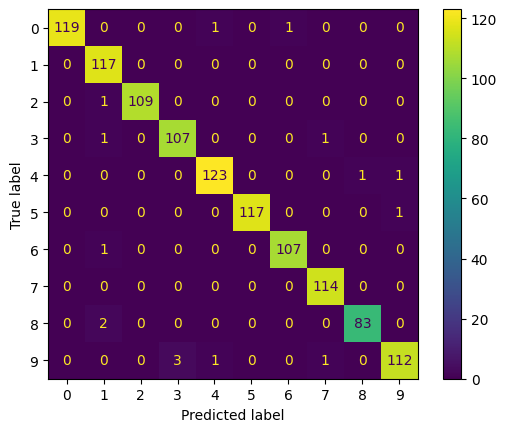

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***SVM for Classification for Gaussian with parameter tuning***

In [ ]:
#SVM for Classification for Gaussian
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='rbf', C=1000, coef0=0.0, gamma='scale', max_iter=-1, shrinking=True, tol=0.001)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_h3 = round(accuracy_score(y_test, y_pred),2)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[111   0   0   0   0   0   0   0   0   0]
 [  0 106   0   0   0   0   0   0   1   0]
 [  0   0 130   0   0   0   0   0   0   0]
 [  0   1   0 132   0   0   0   1   0   0]
 [  0   0   0   0 123   0   1   0   0   0]
 [  0   0   0   0   0 113   0   0   0   1]
 [  0   0   0   0   0   0  90   0   0   0]
 [  0   0   0   0   0   0   0 109   0   0]
 [  0   1   0   0   0   0   0   0 101   0]
 [  0   0   0   0   0   0   0   0   0 103]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       111
           1       0.98      0.99      0.99       107
           2       1.00      1.00      1.00       130
           3       1.00      0.99      0.99       134
           4       1.00      0.99      1.00       124
           5       1.00      0.99      1.00       114
           6       0.99      1.00      0.99        90
           7       0.99      

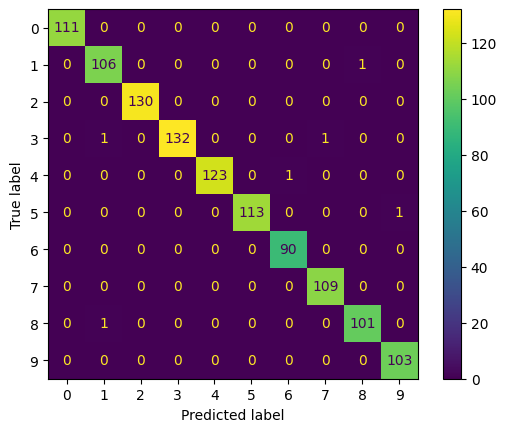

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***Learning Curve for Gaussian SVM without PCA***

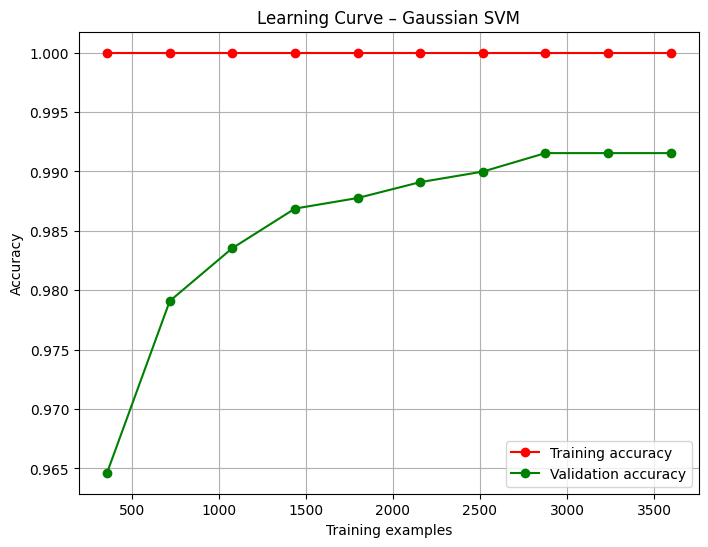

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Example for Gaussian SVM
svc_gaussian = SVC(kernel='rbf', gamma='scale', C=1000, random_state=42, max_iter=-1, shrinking = True, tol = 0.001)

train_sizes, train_scores, test_scores = learning_curve(
    estimator=svc_gaussian,
    X=X_train,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

# mean & std
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

# plot
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training accuracy')
plt.plot(train_sizes, test_mean,  'o-', color='g', label='Validation accuracy')
#plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
#plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.title("Learning Curve – Gaussian SVM")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")           # it's accuracy, not raw loss
plt.legend(loc="best")
plt.grid(True)
plt.show()


# ***Receiver Operating Characteristic(ROC) curve - Gaussian SVM***

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


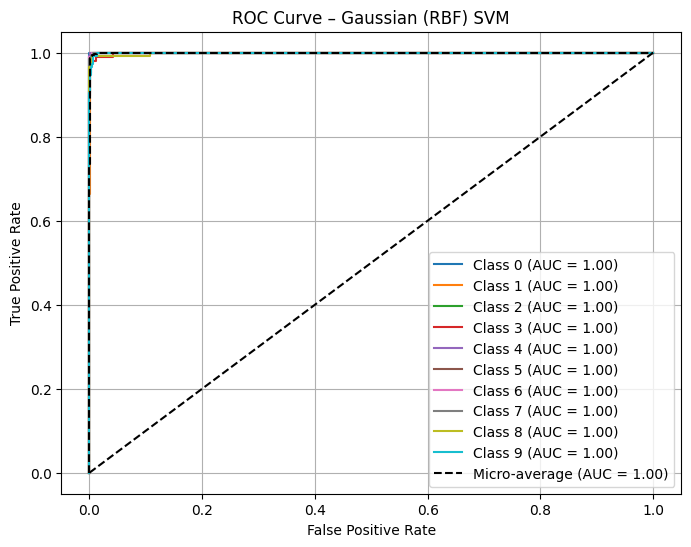

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- Fit the Gaussian (RBF) SVM with probability estimates ---
svc_gaussian = SVC(
    kernel='rbf',
    gamma='scale',     # or 'auto'
    C=1000,            # regularization
    probability=True,  # needed for predict_proba
    random_state=42
)
svc_gaussian.fit(X_train, y_train)

# --- Predict class probabilities ---
y_score = svc_gaussian.predict_proba(X_test)

# --- Binarize the true labels using the same class order ---
y_test_bin = label_binarize(y_test, classes=svc_gaussian.classes_)
n_classes = y_test_bin.shape[1]

# --- Plot ROC for each class ---
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {svc_gaussian.classes_[i]} (AUC = {roc_auc:.2f})")

# --- Micro-average ROC ---
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", color="black",
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# --- Plot settings ---
plt.plot([0, 1], [0, 1], 'k--')  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Gaussian (RBF) SVM")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ***Area Under The Curve(AUC) - Gaussian SVM***

In [ ]:
from sklearn.metrics import roc_auc_score

# y_test_bin must be shape (n_samples, n_classes)
# y_score    must be shape (n_samples, n_classes)
# and the columns must correspond to the same class order as your classifier

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print(f"Macro-average AUC: {roc_auc_macro:.3f}")
print(f"Micro-average AUC: {roc_auc_micro:.3f}")

Macro-average AUC: 1.000
Micro-average AUC: 1.000


# ***After PCA(Principal Component Analysis) - SVM Gaussian***

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- Scale ---
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# --- PCA (reduce to 10 components) ---
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# --- Gaussian SVM ---
svc_gaussian = SVC(
    kernel='rbf',
    gamma='scale',     # or 'auto'
    C=1000,            # regularization
    probability=True,  # needed for predict_proba
    random_state=42
)
svc_gaussian.fit(X_train_pca, y_train)

# --- Predict & Evaluate ---
y_pred = svc_gaussian.predict(X_test_pca)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.943950177935943
Confusion matrix:
 [[108   0   0   0   0   0   0   0   0   0]
 [  0  98   0   1   0   0   0   1   2   0]
 [  0   1 106   0   0   0   0   0   0   0]
 [  0   0   0 108   0   2   0   0   2   6]
 [  0   0   0   0 112   1   1   1   0   2]
 [  0   0   0   0   1  93   0   0   2   1]
 [  0   1   0   0   0   0 122   0   0   0]
 [  0   1   0   0   0   0   0 121   0   2]
 [  0   5   0   7   0   2   0   1  90   0]
 [  0   3   0   8   0   5   0   0   4 103]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       108
           1       0.90      0.96      0.93       102
           2       1.00      0.99      1.00       107
           3       0.87      0.92      0.89       118
           4       0.99      0.96      0.97       117
           5       0.90      0.96      0.93        97
           6       0.99      0.99      0.99       123
           7       0.98      0.98      0.98       124
           

# ***SVM for Classification for Sigmoid***

In [ ]:
#SVM for Classification for Sigmoid
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='sigmoid')
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[ 99   0   0   0   5   0   0   0   0   0]
 [  0  60   2   0  33   0   1   0   7   7]
 [  1   2 102   0   0   0   0   0   8   0]
 [  0   2   0 105   0   1   0   0   7   2]
 [  3   5   0   0 106   0   3   1   5   0]
 [  1   2   1   0   2  87   0   0   4   7]
 [  0   6   0   0   4   0 104   0   0   0]
 [  0   3   0   0   0   0   0 102   3   1]
 [  0  12   0   3  13   1   0   1  78   4]
 [  0   1   1   6   6   0   0   3  11  90]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       104
           1       0.65      0.55      0.59       110
           2       0.96      0.90      0.93       113
           3       0.92      0.90      0.91       117
           4       0.63      0.86      0.73       123
           5       0.98      0.84      0.90       104
           6       0.96      0.91      0.94       114
           7       0.95      

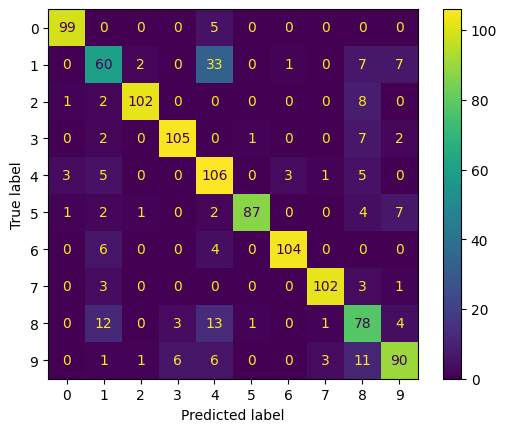

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***SVM for Classification for Sigmoid with parameter tuning***

In [ ]:
#SVM for Classification for Sigmoid
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='sigmoid', probability=True, C=0.1, coef0=-1, gamma='scale', max_iter=-1, shrinking=True, tol=0.001)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_h4 = round(accuracy_score(y_test, y_pred),2)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[113   0   0   0   1   0   0   0   0   0]
 [  0 118   1   0   0   0   0   2   9   3]
 [  0   1 110   0   0   0   0   1   1   0]
 [  0   0   1  93   0   0   0   1   2   1]
 [  0   1   0   0  97   0   2   2   1   0]
 [  0   2   1   0   0 106   0   0   0   2]
 [  0   0   0   0   0   0 107   0   0   0]
 [  0   0   0   1   0   0   0 100   1   0]
 [  0   8   0   0   0   1   1   0 105   5]
 [  0   3   0   1   2   0   0   4   1 112]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       114
           1       0.89      0.89      0.89       133
           2       0.97      0.97      0.97       113
           3       0.98      0.95      0.96        98
           4       0.97      0.94      0.96       103
           5       0.99      0.95      0.97       111
           6       0.97      1.00      0.99       107
           7       0.91      

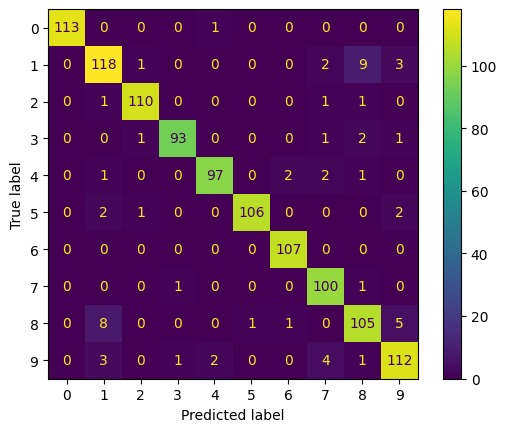

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***Learning Curve for Sigmoid SVM without PCA***

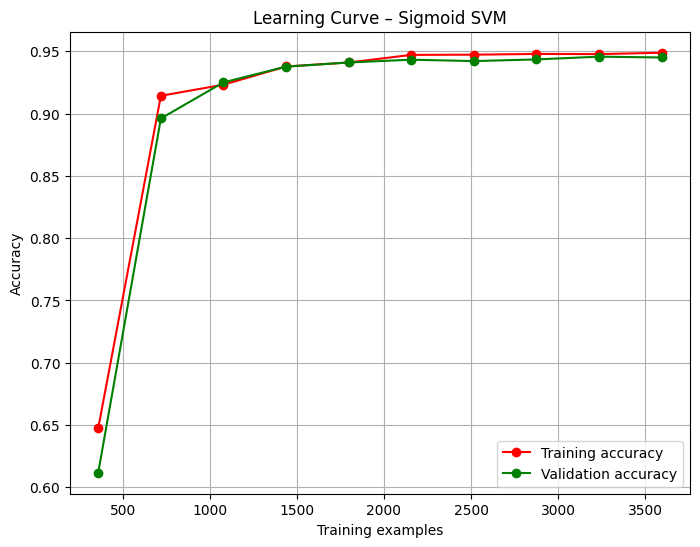

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Example for Gaussian SVM
svc_sigmoid = SVC(
    kernel='sigmoid',
    gamma='scale',     # or 'auto'
    C=0.1,            # regularization
    coef0=-1,
    max_iter=-1,
    shrinking=True,
    tol=0.001,
    probability=True,  # needed for predict_proba
    random_state=42
)
train_sizes, train_scores, test_scores = learning_curve(
    estimator=svc_sigmoid,
    X=X_train,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

# mean & std
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

# plot
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training accuracy')
plt.plot(train_sizes, test_mean,  'o-', color='g', label='Validation accuracy')
#plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
#plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.title("Learning Curve – Sigmoid SVM")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")           # it's accuracy, not raw loss
plt.legend(loc="best")
plt.grid(True)
plt.show()


# ***Receiver Operating Characteristic(ROC) curve - Sigmoid SVM***

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


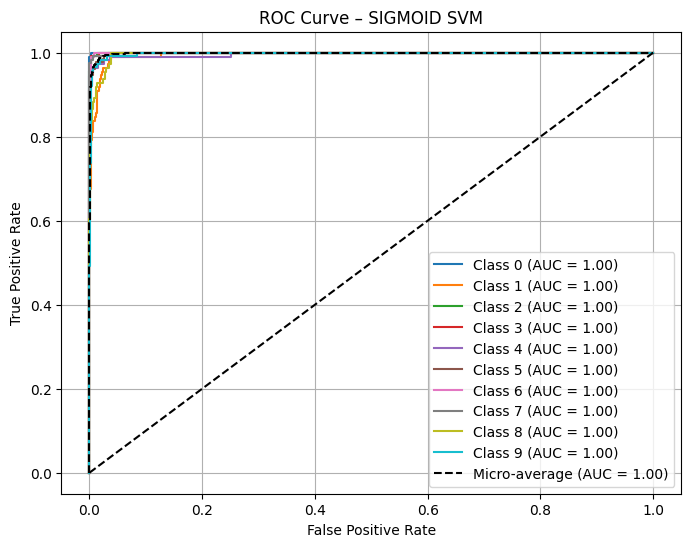

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- Fit the Gaussian (RBF) SVM with probability estimates ---
svc_sigmoid = SVC(
    kernel='sigmoid',
    gamma='scale',     # or 'auto'
    C=0.1,            # regularization
    coef0=-1,
    max_iter=-1,
    shrinking=True,
    tol=0.001,
    probability=True,  # needed for predict_proba
    random_state=42
)
svc_sigmoid.fit(X_train, y_train)

# --- Predict class probabilities ---
y_score = svc_sigmoid.predict_proba(X_test)

# --- Binarize the true labels using the same class order ---
y_test_bin = label_binarize(y_test, classes=svc_sigmoid.classes_)
n_classes = y_test_bin.shape[1]

# --- Plot ROC for each class ---
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {svc_sigmoid.classes_[i]} (AUC = {roc_auc:.2f})")

# --- Micro-average ROC ---
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", color="black",
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# --- Plot settings ---
plt.plot([0, 1], [0, 1], 'k--')  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – SIGMOID SVM")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ***Area Under The Curve(AUC) - Sigmoid SVM***

In [ ]:
from sklearn.metrics import roc_auc_score

# y_test_bin must be shape (n_samples, n_classes)
# y_score    must be shape (n_samples, n_classes)
# and the columns must correspond to the same class order as your classifier

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print(f"Macro-average AUC: {roc_auc_macro:.3f}")
print(f"Micro-average AUC: {roc_auc_micro:.3f}")

Macro-average AUC: 0.998
Micro-average AUC: 0.999


# ***After PCA(Principal Component Analysis) - SVM Sigmoid***

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- Scale ---
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# --- PCA (reduce to 10 components) ---
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# --- Sigmoid SVM ---
svc_sigmoid = SVC(
    kernel='sigmoid',
    gamma='scale',     # or 'auto'
    C=0.1,            # regularization
    coef0=-1,
    max_iter=-1,
    shrinking=True,
    tol=0.001,
    probability=True,  # needed for predict_proba
    random_state=42
)
svc_sigmoid.fit(X_train_pca, y_train)

# --- Predict & Evaluate ---
y_pred = svc_sigmoid.predict(X_test_pca)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.8745551601423488
Confusion matrix:
 [[107   0   0   0   1   0   0   0   0   0]
 [  0  91   5   0   0   0   1   2   2   1]
 [  0   3  91   1   1   0   0   1   9   1]
 [  0   0   0  91   0   3   0   6   6  12]
 [  0   0   0   0  99   2   2   9   2   3]
 [  0   1   0   0   1  79   0   1   6   9]
 [  1   2   0   0   0   0 120   0   0   0]
 [  0   1   0   0   2   0   0 113   2   6]
 [  0   6   0   2   3   2   0   0  88   4]
 [  0   2   0   7   2   3   0   2   3 104]]
Classification report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       108
           1       0.86      0.89      0.88       102
           2       0.95      0.85      0.90       107
           3       0.90      0.77      0.83       118
           4       0.91      0.85      0.88       117
           5       0.89      0.81      0.85        97
           6       0.98      0.98      0.98       123
           7       0.84      0.91      0.88       124
          

# ***Comparison between classifiers***

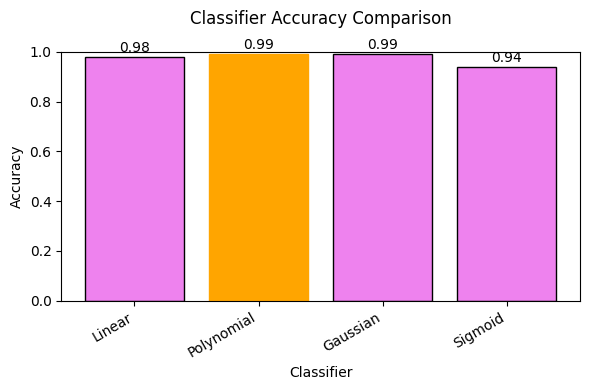

In [ ]:
# Put into DataFrame
df = pd.DataFrame({
    "Result": ["Linear", "Polynomial", "Gaussian", "Sigmoid"],
    "Accuracy": [accuracy_h1, accuracy_h2, accuracy_h3, accuracy_h4]
})

# Identify highest accuracy
max_idx = df["Accuracy"].idxmax()

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(df["Result"], df["Accuracy"], color="violet", edgecolor="black")

# Highlight best bar
bars[max_idx].set_color("orange")

# Add text above bars
for i, val in enumerate(df["Accuracy"]):
    plt.text(i, val + 0.02, f"{val:.2f}", ha="center")

plt.title("Classifier Accuracy Comparison", pad=20)
plt.xlabel("Classifier")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.xticks(rotation=30, ha="right")  # rotate labels so no overlap
plt.tight_layout()                   # auto-adjust spacing
plt.show()


# ***Applying different values of train-test set splits (Eg.: 50:50, 60:40, 70:30 and 80:20) in SVM Polynomial***

In [ ]:
#SVM for Classification for Poly
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='poly', degree=3, gamma='auto') #default degree=3 only for poly
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_hs1 = round(accuracy_score(y_test, y_pred),2)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

#SVM for Classification for Poly
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='poly', degree=3, gamma='auto') #default degree=3 only for poly
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_hs2 = round(accuracy_score(y_test, y_pred),2)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

#SVM for Classification for Poly
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='poly', degree=3, gamma='auto') #default degree=3 only for poly
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_hs3 = round(accuracy_score(y_test, y_pred),2)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

#SVM for Classification for Poly
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.50)

# Classification using simple SVM
from sklearn.svm import SVC
classifier = SVC(kernel='poly', degree=3, gamma='auto') #default degree=3 only for poly
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_hs4 = round(accuracy_score(y_test, y_pred),2)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("----------------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[100   0   0   0   0   0   0   0   0   0]
 [  0 108   0   0   0   0   0   0   0   1]
 [  0   0 131   0   0   0   0   0   0   0]
 [  0   0   0 108   0   0   0   0   0   1]
 [  1   0   0   0 100   0   1   0   0   0]
 [  0   0   0   0   0 132   0   0   0   0]
 [  0   0   0   0   0   0 103   0   0   0]
 [  0   0   0   1   0   0   0 113   0   1]
 [  0   2   0   0   0   0   0   0  97   1]
 [  0   0   0   0   0   2   0   0   0 121]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       100
           1       0.98      0.99      0.99       109
           2       1.00      1.00      1.00       131
           3       0.99      0.99      0.99       109
           4       1.00      0.98      0.99       102
           5       0.99      1.00      0.99       132
           6       0.99      1.00      1.00       103
           7       1.00      

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[150   0   0   0   0   0   0   0   0   0]
 [  0 164   0   0   0   0   0   0   2   0]
 [  0   0 163   0   0   0   0   0   0   1]
 [  0   0   0 166   0   2   0   0   1   0]
 [  1   0   0   0 176   0   1   0   0   0]
 [  0   0   0   1   0 172   0   0   1   1]
 [  0   0   0   0   0   0 159   0   0   0]
 [  0   0   0   0   0   0   0 175   0   2]
 [  0   3   0   0   0   0   0   0 166   0]
 [  0   0   0   1   1   1   0   0   1 175]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       150
           1       0.98      0.99      0.98       166
           2       1.00      0.99      1.00       164
           3       0.99      0.98      0.99       169
           4       0.99      0.99      0.99       178
           5       0.98      0.98      0.98       175
           6       0.99      1.00      1.00       159
           7       1.00      

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[216   0   1   0   1   0   1   0   0   0]
 [  0 235   0   0   0   0   0   0   0   1]
 [  0   0 221   0   0   0   1   0   0   0]
 [  0   1   0 208   0   1   0   0   0   0]
 [  0   0   0   0 229   0   1   0   0   0]
 [  0   0   0   2   0 223   0   0   1   0]
 [  0   3   0   0   0   0 208   0   0   0]
 [  0   0   0   0   0   0   0 236   0   1]
 [  0   6   0   1   0   0   0   0 204   2]
 [  0   1   0   0   1   1   0   2   0 239]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       219
           1       0.96      1.00      0.98       236
           2       1.00      1.00      1.00       222
           3       0.99      0.99      0.99       210
           4       0.99      1.00      0.99       230
           5       0.99      0.99      0.99       226
           6       0.99      0.99      0.99       211
           7       0.99      

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[281   0   0   0   0   0   0   0   0   0]
 [  0 302   0   0   0   0   0   1   3   0]
 [  0   0 285   0   0   0   0   0   0   0]
 [  0   0   0 280   0   1   0   2   0   2]
 [  0   0   0   0 277   0   0   0   0   3]
 [  0   0   0   2   0 282   0   0   1   2]
 [  1   0   0   0   2   0 254   0   1   0]
 [  0   0   0   0   0   0   0 283   0   0]
 [  0   2   0   0   0   1   0   0 261   0]
 [  0   0   0   1   0   1   0   3   2 274]]
----------------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       281
           1       0.99      0.99      0.99       306
           2       1.00      1.00      1.00       285
           3       0.99      0.98      0.99       285
           4       0.99      0.99      0.99       280
           5       0.99      0.98      0.99       287
           6       1.00      0.98      0.99       258
           7       0.98      

# ***Comparion of train-test split values***

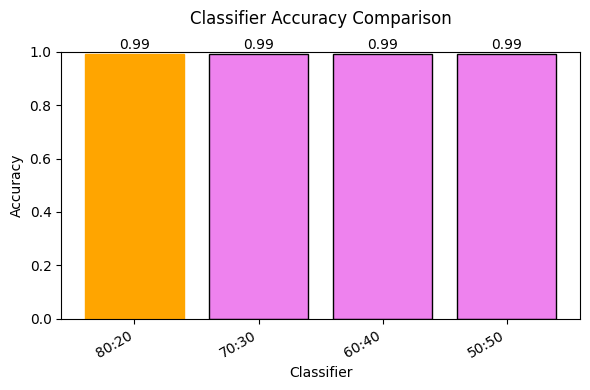

In [ ]:
# Put into DataFrame
df = pd.DataFrame({
    "Result": ["80:20", "70:30", "60:40", "50:50"],
    "Accuracy": [accuracy_hs1, accuracy_hs2, accuracy_hs3, accuracy_hs4]
})

# Identify highest accuracy
max_idx = df["Accuracy"].idxmax()

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(df["Result"], df["Accuracy"], color="violet", edgecolor="black")

# Highlight best bar
bars[max_idx].set_color("orange")

# Add text above bars
for i, val in enumerate(df["Accuracy"]):
    plt.text(i, val + 0.02, f"{val:.2f}", ha="center")

plt.title("Classifier Accuracy Comparison", pad=20)
plt.xlabel("Classifier")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.xticks(rotation=30, ha="right")  # rotate labels so no overlap
plt.tight_layout()                   # auto-adjust spacing
plt.show()


# ***MLP Classifier without Parameter Tuning***

In [ ]:
# MLP for Classification
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using MLP
from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier() # Instantiate the classifier
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("------------------------------------")
print("------------------------------------")

print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[ 98   0   0   0   0   0   0   0   0   0]
 [  0 118   0   0   0   0   1   0   2   0]
 [  0   0 110   0   0   2   0   0   0   0]
 [  0   0   0 108   0   1   0   0   0   1]
 [  0   1   0   0 106   0   1   0   1   0]
 [  0   0   0   1   0 106   0   0   0   1]
 [  0   1   0   0   0   0 112   0   0   0]
 [  0   0   0   0   0   0   0 114   0   0]
 [  1   2   0   0   0   0   0   0 128   1]
 [  0   2   1   1   1   0   0   1   1 100]]
------------------------------------
------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        98
           1       0.95      0.98      0.96       121
           2       0.99      0.98      0.99       112
           3       0.98      0.98      0.98       110
           4       0.99      0.97      0.98       109
           5       0.97      0.98      0.98       108
           6       0.98      0.99      0.99       113
           7       0

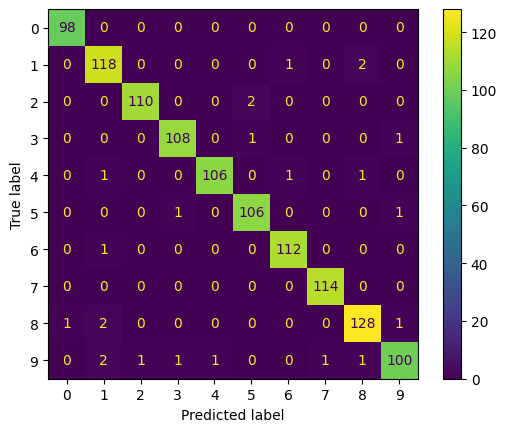

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***MLP Classifier with Momentum Parameter Tuning***

In [ ]:
#MLP for Classification

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using MLP

from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(100, 100, 100), momentum=0.9)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_mh1 = round(accuracy_score(y_test, y_pred),2)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("-------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[113   0   0   0   0   0   0   0   0   0]
 [  0 101   1   0   0   0   0   0   1   0]
 [  0   0 110   0   0   0   0   1   0   1]
 [  0   0   0 118   0   0   0   0   0   0]
 [  0   0   0   0  96   0   0   0   0   0]
 [  0   0   0   0   0 112   0   0   1   0]
 [  0   0   0   0   0   0 131   0   0   0]
 [  0   0   0   2   0   0   0 114   0   1]
 [  0   3   0   0   0   0   0   0 107   0]
 [  0   0   0   2   0   1   0   0   0 108]]
-------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       0.97      0.98      0.98       103
           2       0.99      0.98      0.99       112
           3       0.97      1.00      0.98       118
           4       1.00      1.00      1.00        96
           5       0.99      0.99      0.99       113
           6       1.00      1.00      1.00       131
           7       0.99      0.97     

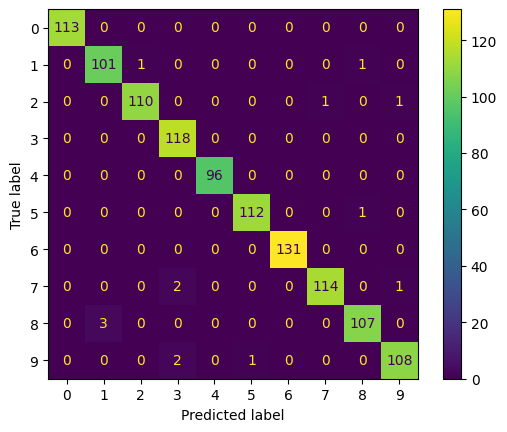

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***Learning Curve and training and loss generation curve - Momemtum MLP***

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


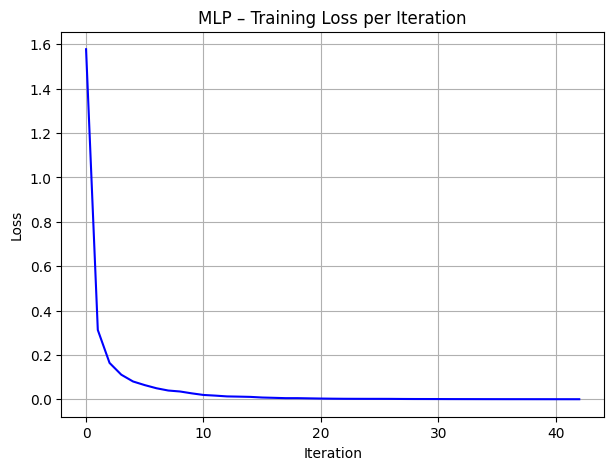

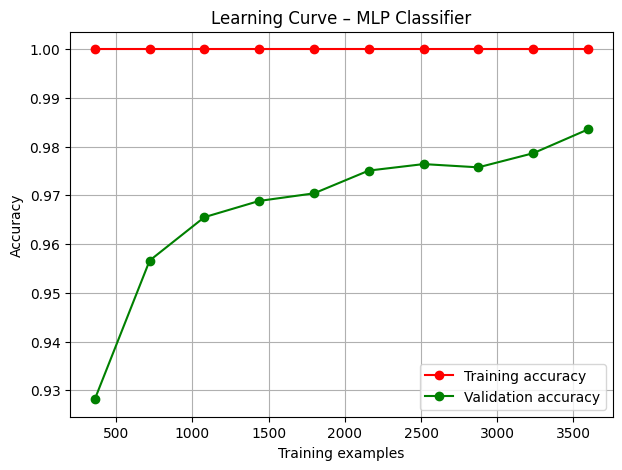

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Fit an MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,100,100),  # tweak if you want
    momentum=0.9
)

mlp.fit(X_train, y_train)

# --- 2. Plot LOSS curve (iterations vs loss) ---
plt.figure(figsize=(7, 5))
plt.plot(mlp.loss_curve_, 'b-')
plt.title("MLP – Training Loss per Iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# --- 3. Learning curve (accuracy vs training size) ---
train_sizes, train_scores, test_scores = learning_curve(
    estimator=mlp,
    X=X_train,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training accuracy')
plt.plot(train_sizes, test_mean,  'o-', color='g', label='Validation accuracy')
# Optional shaded error bands:
# plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
# plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.title("Learning Curve – MLP Classifier")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()


# ***Receiver Operating Characteristic(ROC) curve - Momentum MLP***

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


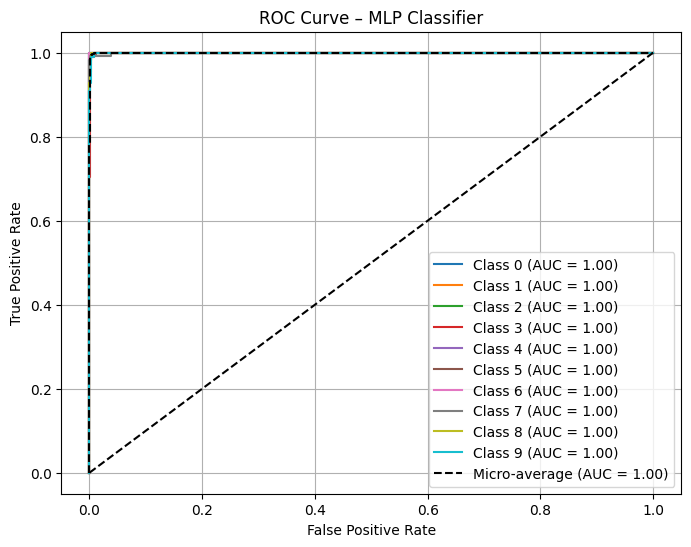

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- 1. Fit MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,100,100),   # change if you want more neurons/layers
    momentum=0.9
)
mlp.fit(X_train, y_train)

# --- 2. Predict class probabilities ---
y_score = mlp.predict_proba(X_test)

# --- 3. Binarize true labels (match the model's class order) ---
y_test_bin = label_binarize(y_test, classes=mlp.classes_)
n_classes = y_test_bin.shape[1]

# --- 4. Plot ROC curve for each class ---
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {mlp.classes_[i]} (AUC = {roc_auc:.2f})")

# --- 5. Micro-average ROC (all classes combined) ---
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", color="black",
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# --- 6. Plot settings ---
plt.plot([0, 1], [0, 1], 'k--')  # diagonal = random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MLP Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ***Area Under The Curve(AUC) - Momentum MLP***

In [ ]:
from sklearn.metrics import roc_auc_score

# y_test_bin must be shape (n_samples, n_classes)
# y_score    must be shape (n_samples, n_classes)
# and the columns must correspond to the same class order as your classifier

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print(f"Macro-average AUC: {roc_auc_macro:.3f}")
print(f"Micro-average AUC: {roc_auc_micro:.3f}")

Macro-average AUC: 1.000
Micro-average AUC: 1.000


# ***After PCA(Principal Component Analysis) - Momentum MLP***

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# --- Scale (MLPs need scaled inputs) ---
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# --- Define MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),   # you can tune (e.g., (64, 32) for two layers)
    momentum=0.9
)

# --- Fit ---
mlp.fit(X_train_scaled, y_train)

# --- Predict & Evaluate ---
y_pred = mlp.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.9822064056939501
Confusion matrix:
 [[108   0   0   0   0   0   0   0   0   0]
 [  0 102   0   0   0   0   0   0   0   0]
 [  0   0 106   0   0   0   0   0   0   1]
 [  0   0   1 114   0   3   0   0   0   0]
 [  0   0   0   0 114   0   1   0   0   2]
 [  0   0   0   1   0  95   0   0   0   1]
 [  1   2   0   0   0   0 120   0   0   0]
 [  0   0   0   0   0   0   0 124   0   0]
 [  0   0   0   0   1   0   0   0 104   0]
 [  0   1   0   3   0   1   0   0   1 117]]
Classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       108
           1       0.97      1.00      0.99       102
           2       0.99      0.99      0.99       107
           3       0.97      0.97      0.97       118
           4       0.99      0.97      0.98       117
           5       0.96      0.98      0.97        97
           6       0.99      0.98      0.98       123
           7       1.00      1.00      1.00       124
          

# ***MLP Classifier with Epoch size Parameter Tuning***

In [ ]:
#MLP for Classification

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using MLP

from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(100, 100, 100), max_iter=300)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_mh2 = round(accuracy_score(y_test, y_pred),2)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("-------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[108   0   1   0   0   0   0   0   0   0]
 [  0 114   1   0   0   0   0   0   0   0]
 [  0   1  99   0   0   0   0   0   0   0]
 [  0   0   1  96   0   1   0   0   0   0]
 [  0   0   0   0 114   0   2   0   0   0]
 [  0   0   0   1   0 100   1   0   0   1]
 [  0   0   0   0   0   0 123   0   0   0]
 [  0   0   0   1   0   0   0 116   0   0]
 [  0   6   0   0   0   1   0   0 115   0]
 [  0   1   0   0   0   0   0   0   0 120]]
-------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       109
           1       0.93      0.99      0.96       115
           2       0.97      0.99      0.98       100
           3       0.98      0.98      0.98        98
           4       1.00      0.98      0.99       116
           5       0.98      0.97      0.98       103
           6       0.98      1.00      0.99       123
           7       1.00      0.99     

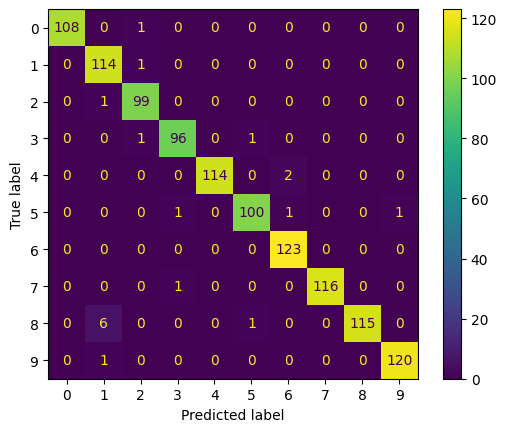

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***Learning Curve and training and loss generation curve - Epoch size MLP***

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


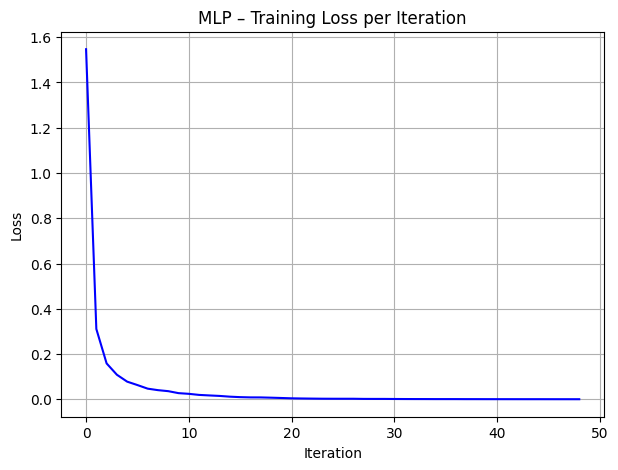

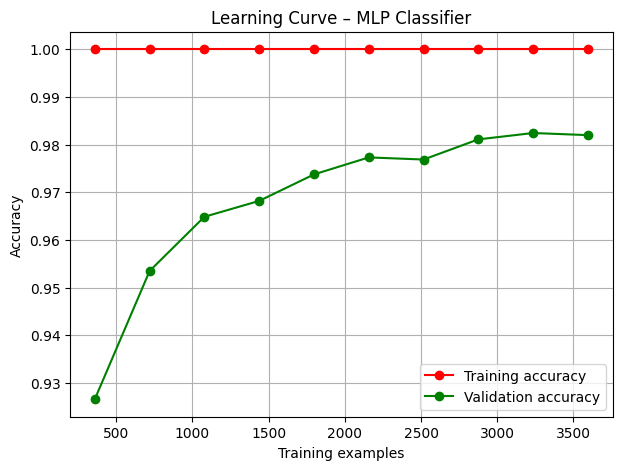

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Fit an MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,100,100),  # tweak if you want
    max_iter=300
)

mlp.fit(X_train, y_train)

# --- 2. Plot LOSS curve (iterations vs loss) ---
plt.figure(figsize=(7, 5))
plt.plot(mlp.loss_curve_, 'b-')
plt.title("MLP – Training Loss per Iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# --- 3. Learning curve (accuracy vs training size) ---
train_sizes, train_scores, test_scores = learning_curve(
    estimator=mlp,
    X=X_train,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training accuracy')
plt.plot(train_sizes, test_mean,  'o-', color='g', label='Validation accuracy')
# Optional shaded error bands:
# plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
# plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.title("Learning Curve – MLP Classifier")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()


# ***Receiver Operating Characteristic(ROC) curve - Epoch size MLP***

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


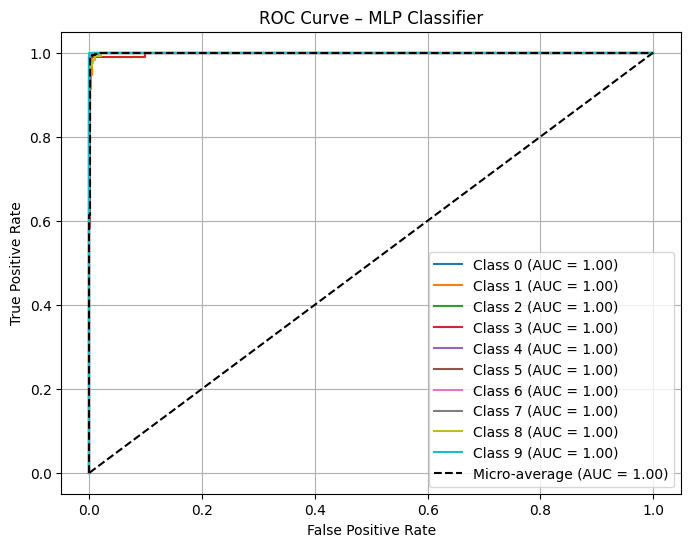

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- 1. Fit MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,100,100),   # change if you want more neurons/layers
    max_iter=300
)
mlp.fit(X_train, y_train)

# --- 2. Predict class probabilities ---
y_score = mlp.predict_proba(X_test)

# --- 3. Binarize true labels (match the model's class order) ---
y_test_bin = label_binarize(y_test, classes=mlp.classes_)
n_classes = y_test_bin.shape[1]

# --- 4. Plot ROC curve for each class ---
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {mlp.classes_[i]} (AUC = {roc_auc:.2f})")

# --- 5. Micro-average ROC (all classes combined) ---
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", color="black",
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# --- 6. Plot settings ---
plt.plot([0, 1], [0, 1], 'k--')  # diagonal = random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MLP Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ***Area Under The Curve(AUC) - Epoch size MLP***

In [ ]:
from sklearn.metrics import roc_auc_score

# y_test_bin must be shape (n_samples, n_classes)
# y_score    must be shape (n_samples, n_classes)
# and the columns must correspond to the same class order as your classifier

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print(f"Macro-average AUC: {roc_auc_macro:.3f}")
print(f"Micro-average AUC: {roc_auc_micro:.3f}")

Macro-average AUC: 1.000
Micro-average AUC: 1.000


# ***After PCA(Principal Component Analysis) - Momentum MLP***

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# --- Scale (MLPs need scaled inputs) ---
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# --- Define MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),   # you can tune (e.g., (64, 32) for two layers)
    max_iter=300
)

# --- Fit ---
mlp.fit(X_train_scaled, y_train)

# --- Predict & Evaluate ---
y_pred = mlp.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.9822064056939501
Confusion matrix:
 [[107   0   0   0   0   0   1   0   0   0]
 [  0 102   0   0   0   0   0   0   0   0]
 [  0   0 106   0   0   0   0   0   0   1]
 [  0   0   0 115   0   3   0   0   0   0]
 [  0   0   0   0 117   0   0   0   0   0]
 [  0   0   0   1   1  94   0   0   0   1]
 [  0   2   0   0   1   0 120   0   0   0]
 [  0   1   0   0   0   0   0 123   0   0]
 [  0   0   0   0   1   0   0   0 104   0]
 [  0   2   0   1   0   1   0   0   3 116]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       108
           1       0.95      1.00      0.98       102
           2       1.00      0.99      1.00       107
           3       0.98      0.97      0.98       118
           4       0.97      1.00      0.99       117
           5       0.96      0.97      0.96        97
           6       0.99      0.98      0.98       123
           7       1.00      0.99      1.00       124
          

# ***MLP Classifier with Learning Rate Parameter Tuning***

In [ ]:
#MLP for Classification

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using MLP

from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(100, 100, 100), learning_rate_init=0.01)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_mh3 = round(accuracy_score(y_test, y_pred),2)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("-------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[122   0   0   0   0   0   0   0   0   0]
 [  0 102   0   1   0   0   0   0   4   3]
 [  0   0 113   0   0   0   0   0   0   0]
 [  0   0   1 105   0   0   0   1   1   1]
 [  1   0   0   0 102   1   0   0   0   0]
 [  0   0   0   1   0 105   0   0   0   1]
 [  0   0   0   0   0   0 104   0   1   0]
 [  0   0   0   0   0   0   0 111   0   2]
 [  1   1   0   0   0   2   0   0 109   1]
 [  1   0   0   1   0   4   0   0   2 119]]
-------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       122
           1       0.99      0.93      0.96       110
           2       0.99      1.00      1.00       113
           3       0.97      0.96      0.97       109
           4       1.00      0.98      0.99       104
           5       0.94      0.98      0.96       107
           6       1.00      0.99      1.00       105
           7       0.99      0.98     

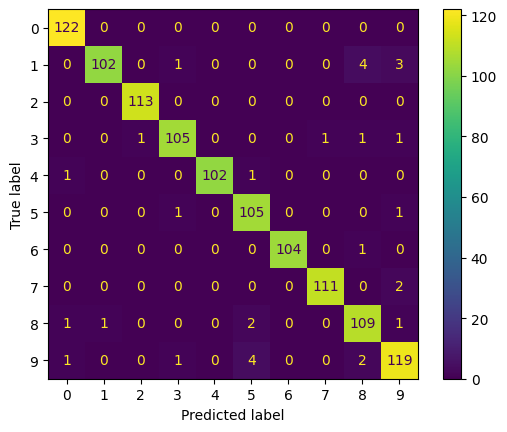

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***Learning Curve and training and loss generation curve - Learning rate MLP***

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


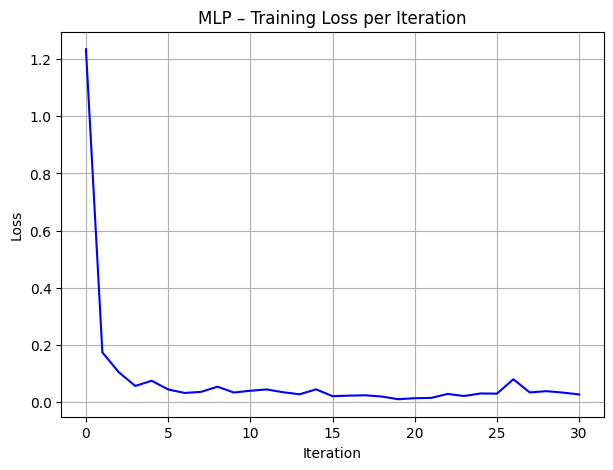

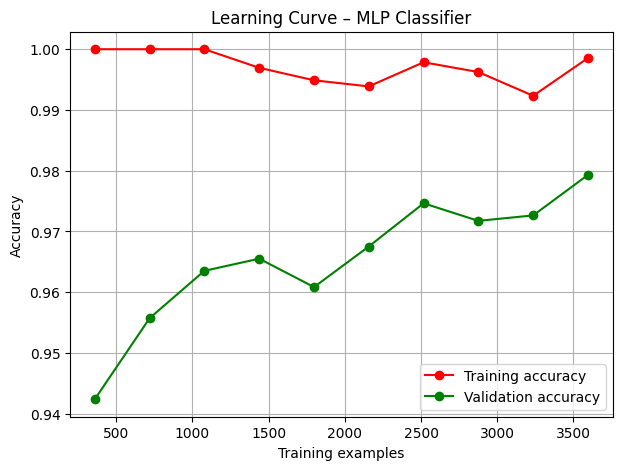

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Fit an MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,100,100),  # tweak if you want
    learning_rate_init=0.01
)

mlp.fit(X_train, y_train)

# --- 2. Plot LOSS curve (iterations vs loss) ---
plt.figure(figsize=(7, 5))
plt.plot(mlp.loss_curve_, 'b-')
plt.title("MLP – Training Loss per Iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# --- 3. Learning curve (accuracy vs training size) ---
train_sizes, train_scores, test_scores = learning_curve(
    estimator=mlp,
    X=X_train,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training accuracy')
plt.plot(train_sizes, test_mean,  'o-', color='g', label='Validation accuracy')
# Optional shaded error bands:
# plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
# plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.title("Learning Curve – MLP Classifier")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()


# ***Receiver Operating Characteristic(ROC) curve - Learning rate MLP***

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


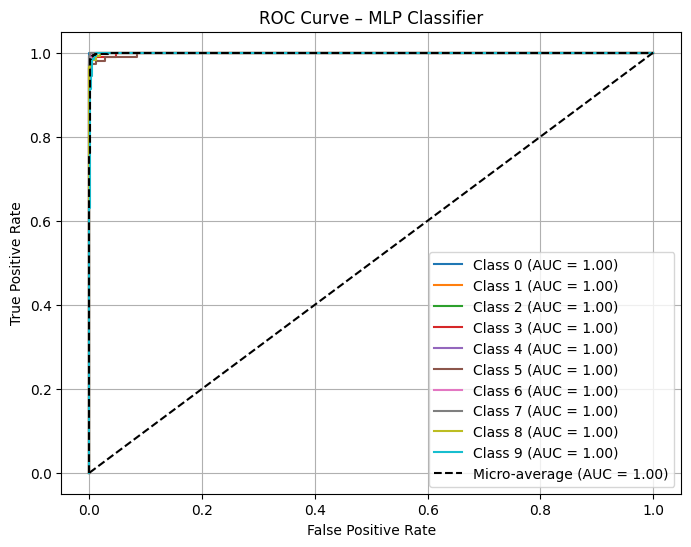

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- 1. Fit MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,100,100),   # change if you want more neurons/layers
    learning_rate_init=0.01
)
mlp.fit(X_train, y_train)

# --- 2. Predict class probabilities ---
y_score = mlp.predict_proba(X_test)

# --- 3. Binarize true labels (match the model's class order) ---
y_test_bin = label_binarize(y_test, classes=mlp.classes_)
n_classes = y_test_bin.shape[1]

# --- 4. Plot ROC curve for each class ---
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {mlp.classes_[i]} (AUC = {roc_auc:.2f})")

# --- 5. Micro-average ROC (all classes combined) ---
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", color="black",
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# --- 6. Plot settings ---
plt.plot([0, 1], [0, 1], 'k--')  # diagonal = random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MLP Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ***Area Under The Curve(AUC) - Learning rate MLP***

In [ ]:
from sklearn.metrics import roc_auc_score

# y_test_bin must be shape (n_samples, n_classes)
# y_score    must be shape (n_samples, n_classes)
# and the columns must correspond to the same class order as your classifier

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print(f"Macro-average AUC: {roc_auc_macro:.3f}")
print(f"Micro-average AUC: {roc_auc_micro:.3f}")

Macro-average AUC: 1.000
Micro-average AUC: 1.000


# ***After PCA(Principal Component Analysis) - Learning rate MLP***

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# --- Scale (MLPs need scaled inputs) ---
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# --- Define MLP ---
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),   # you can tune (e.g., (64, 32) for two layers)
    learning_rate_init=0.01
)

# --- Fit ---
mlp.fit(X_train_scaled, y_train)

# --- Predict & Evaluate ---
y_pred = mlp.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.9777580071174378
Confusion matrix:
 [[107   0   0   0   0   0   1   0   0   0]
 [  0 101   0   1   0   0   0   0   0   0]
 [  0   0 106   0   0   0   0   0   0   1]
 [  0   0   1 114   0   3   0   0   0   0]
 [  0   0   0   0 114   0   1   0   0   2]
 [  0   0   0   1   1  94   0   0   1   0]
 [  0   1   0   0   1   0 121   0   0   0]
 [  0   0   0   0   0   0   0 124   0   0]
 [  0   1   0   0   2   0   0   0 102   0]
 [  0   2   0   1   0   1   0   0   3 116]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       108
           1       0.96      0.99      0.98       102
           2       0.99      0.99      0.99       107
           3       0.97      0.97      0.97       118
           4       0.97      0.97      0.97       117
           5       0.96      0.97      0.96        97
           6       0.98      0.98      0.98       123
           7       1.00      1.00      1.00       124
          

# ***Comparison of MLP Parameters***

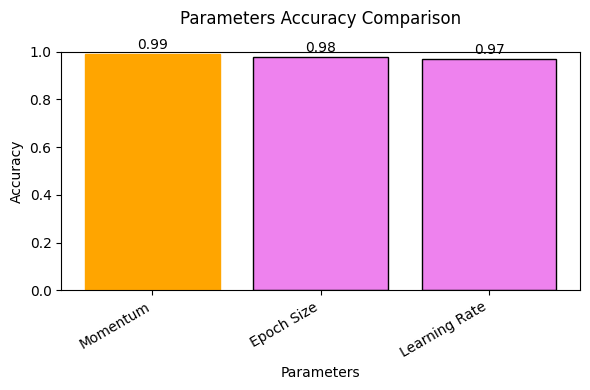

In [ ]:
# Put into DataFrame
df = pd.DataFrame({
    "Result": ["Momentum", "Epoch Size", "Learning Rate"],
    "Accuracy": [accuracy_mh1, accuracy_mh2, accuracy_mh3]
})

# Identify highest accuracy
max_idx = df["Accuracy"].idxmax()

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(df["Result"], df["Accuracy"], color="violet", edgecolor="black")

# Highlight best bar
bars[max_idx].set_color("orange")

# Add text above bars
for i, val in enumerate(df["Accuracy"]):
    plt.text(i, val + 0.02, f"{val:.2f}", ha="center")

plt.title("Parameters Accuracy Comparison", pad=20)
plt.xlabel("Parameters")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.xticks(rotation=30, ha="right")  # rotate labels so no overlap
plt.tight_layout()                   # auto-adjust spacing
plt.show()


# ***MLP Classifier with Momentum in different test-train split values***

In [ ]:
#MLP for Classification

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using MLP

from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(100, 100, 100), momentum=0.9)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_mht1 = round(accuracy_score(y_test, y_pred),2)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("-------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

#MLP for Classification

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

# Classification using MLP

from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(100, 100, 100), momentum=0.9)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_mht2 = round(accuracy_score(y_test, y_pred),2)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("-------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

#MLP for Classification

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Classification using MLP

from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(100, 100, 100), momentum=0.9)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_mh1 = round(accuracy_score(y_test, y_pred),2)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("-------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

#MLP for Classification

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40)

# Classification using MLP

from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(100, 100, 100), momentum=0.9)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_mht3 = round(accuracy_score(y_test, y_pred),2)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("-------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

#MLP for Classification

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.50)

# Classification using MLP

from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(100, 100, 100), momentum=0.9)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_mht4 = round(accuracy_score(y_test, y_pred),2)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("-------------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[115   0   0   0   0   0   0   0   0   0]
 [  0 123   0   0   0   0   0   1   0   0]
 [  0   0 111   1   0   0   0   2   0   0]
 [  0   0   0 117   0   0   0   1   0   0]
 [  1   1   0   0 114   0   0   0   0   1]
 [  0   0   0   2   0  94   0   0   1   2]
 [  1   2   0   0   0   0 115   0   0   0]
 [  0   0   0   0   1   0   0 107   0   0]
 [  0   2   1   1   0   0   0   0 103   0]
 [  0   1   0   1   1   0   0   0   2  99]]
-------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       115
           1       0.95      0.99      0.97       124
           2       0.99      0.97      0.98       114
           3       0.96      0.99      0.97       118
           4       0.98      0.97      0.98       117
           5       1.00      0.95      0.97        99
           6       1.00      0.97      0.99       118
           7       0.96      0.99     

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[161   0   1   0   1   0   0   0   0   0]
 [  0 172   0   0   0   0   0   0   1   0]
 [  0   0 170   0   0   0   0   0   1   0]
 [  0   0   0 154   0   1   0   0   1   0]
 [  0   0   0   0 182   0   2   0   0   0]
 [  0   0   0   0   0 167   0   0   0   2]
 [  0   1   0   0   0   0 158   0   1   0]
 [  0   0   0   0   0   0   0 167   0   1]
 [  0   2   1   0   0   0   0   1 171   0]
 [  0   1   0   0   2   1   0   0   1 162]]
-------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       163
           1       0.98      0.99      0.99       173
           2       0.99      0.99      0.99       171
           3       1.00      0.99      0.99       156
           4       0.98      0.99      0.99       184
           5       0.99      0.99      0.99       169
           6       0.99      0.99      0.99       160
           7       0.99      0.99     

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[107   0   0   0   0   0   0   0   0   0]
 [  0 117   0   0   0   0   0   0   1   0]
 [  0   0 116   0   0   0   0   0   0   0]
 [  0   1   0  99   0   0   0   1   1   0]
 [  1   0   0   0 112   0   0   0   0   2]
 [  0   0   0   2   0 105   0   0   1   1]
 [  0   0   0   0   0   0 114   0   1   0]
 [  0   0   0   1   0   0   0 103   1   1]
 [  0   2   0   0   0   0   0   0 117   0]
 [  0   1   0   0   0   0   0   0   1 115]]
-------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       107
           1       0.97      0.99      0.98       118
           2       1.00      1.00      1.00       116
           3       0.97      0.97      0.97       102
           4       1.00      0.97      0.99       115
           5       1.00      0.96      0.98       109
           6       1.00      0.99      1.00       115
           7       0.99      0.97     

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[236   0   1   0   1   0   1   0   0   0]
 [  0 215   0   0   0   0   0   1   1   0]
 [  0   1 212   0   0   0   2   0   0   1]
 [  0   0   0 220   0   1   0   2   0   1]
 [  0   0   0   0 201   0   2   0   0   1]
 [  0   0   1   2   0 228   1   1   1   4]
 [  0   0   0   0   0   0 229   0   0   0]
 [  0   0   1   0   2   0   0 229   0   1]
 [  0   6   0   0   0   0   1   0 193   0]
 [  1   0   0   0   0   2   0   2   1 242]]
-------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       239
           1       0.97      0.99      0.98       217
           2       0.99      0.98      0.98       216
           3       0.99      0.98      0.99       224
           4       0.99      0.99      0.99       204
           5       0.99      0.96      0.97       238
           6       0.97      1.00      0.98       229
           7       0.97      0.98     

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[273   0   0   0   1   0   0   0   3   0]
 [  1 270   0   0   1   1   2   2   3   1]
 [  0   1 281   0   0   0   1   0   1   1]
 [  0   0   4 280   0   4   0   3   1   5]
 [  1   0   0   0 275   0   2   0   0   5]
 [  1   0   0   2   1 268   0   0   1   3]
 [  0   0   0   0   0   1 280   0   0   0]
 [  0   0   0   0   0   5   0 285   2   0]
 [  0   5   0   1   0   3   0   0 254   1]
 [  0   2   0   1   1   1   0   3   2 264]]
-------------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       277
           1       0.97      0.96      0.97       281
           2       0.99      0.99      0.99       285
           3       0.99      0.94      0.96       297
           4       0.99      0.97      0.98       283
           5       0.95      0.97      0.96       276
           6       0.98      1.00      0.99       281
           7       0.97      0.98     

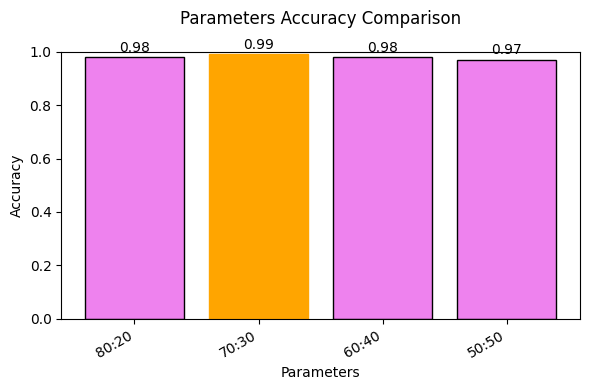

In [ ]:
# Put into DataFrame
df = pd.DataFrame({
    "Result": ["80:20", "70:30", "60:40", "50:50"],
    "Accuracy": [accuracy_mht1, accuracy_mht2, accuracy_mht3, accuracy_mht4]
})

# Identify highest accuracy
max_idx = df["Accuracy"].idxmax()

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(df["Result"], df["Accuracy"], color="violet", edgecolor="black")

# Highlight best bar
bars[max_idx].set_color("orange")

# Add text above bars
for i, val in enumerate(df["Accuracy"]):
    plt.text(i, val + 0.02, f"{val:.2f}", ha="center")

plt.title("Parameters Accuracy Comparison", pad=20)
plt.xlabel("Parameters")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.xticks(rotation=30, ha="right")  # rotate labels so no overlap
plt.tight_layout()                   # auto-adjust spacing
plt.show()


# ***Random Forest Classifier with Parametr Tuning***

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20,random_state=0)

# Feature Scaling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Classification
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42)
classifier.fit(X_train,y_train)

y_pred = classifier.predict(X_test)

# Evaluation of Classifier Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("--------------------------------------------------")
print("--------------------------------------------------")

print("Performance Evaluation:")
print(classification_report(y_test, y_pred))

print("--------------------------------------------------")
print("--------------------------------------------------")

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Confusion Matrix:
[[130   0   0   0   0   0   0   0   0   0]
 [  0 112   0   0   0   0   0   0   0   1]
 [  0   0 112   0   0   0   0   0   0   0]
 [  0   0   1 110   0   0   0   0   1   1]
 [  0   0   0   0  98   0   0   0   0   2]
 [  0   0   0   1   0 119   0   0   0   1]
 [  0   1   0   0   1   0 120   0   0   0]
 [  0   0   0   0   1   0   0 121   0   0]
 [  0   0   0   0   0   0   1   0  96   1]
 [  0   0   0   0   1   0   0   2   0  90]]
--------------------------------------------------
--------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       130
           1       0.99      0.99      0.99       113
           2       0.99      1.00      1.00       112
           3       0.99      0.97      0.98       113
           4       0.97      0.98      0.98       100
           5       1.00      0.98      0.99       121
           6       0.99      0.98      0.99   

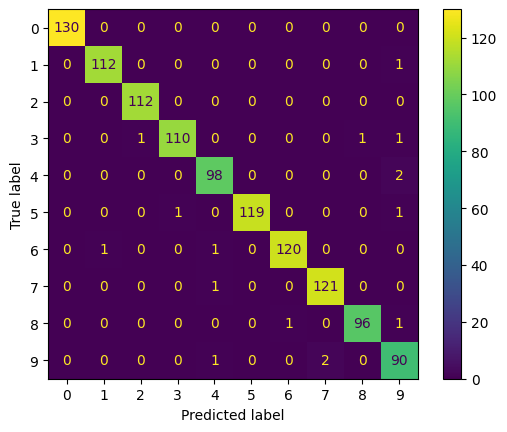

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

# ***Learning Curve for Random Forest***

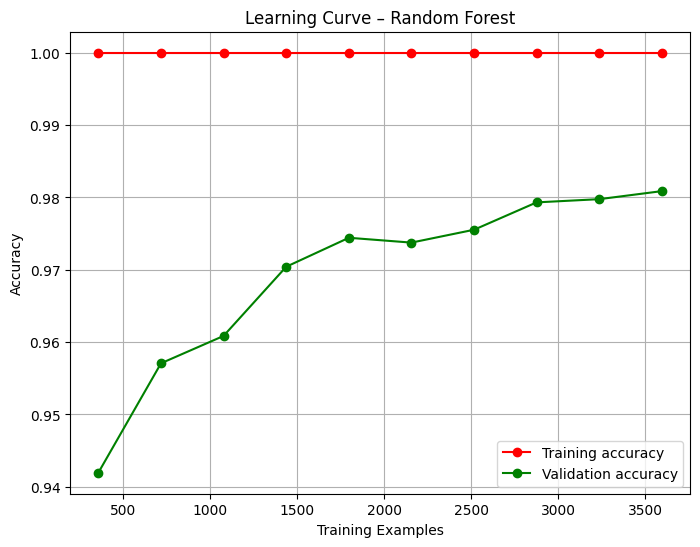

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# --- Random Forest Classifier ---
rf_clf = RandomForestClassifier(n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42)

# --- Learning curve ---
train_sizes, train_scores, test_scores = learning_curve(
    estimator=rf_clf,
    X=X_train,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

# --- Mean & Std ---
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training accuracy")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Validation accuracy")

# Optional shading for std
# plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
# plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("Learning Curve – Random Forest")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")   # Accuracy is correct metric here (not raw loss)
plt.legend(loc="best")
plt.grid(True)
plt.show()


# ***Receiver Operating Characteristic(ROC) curve - Random Forest***

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


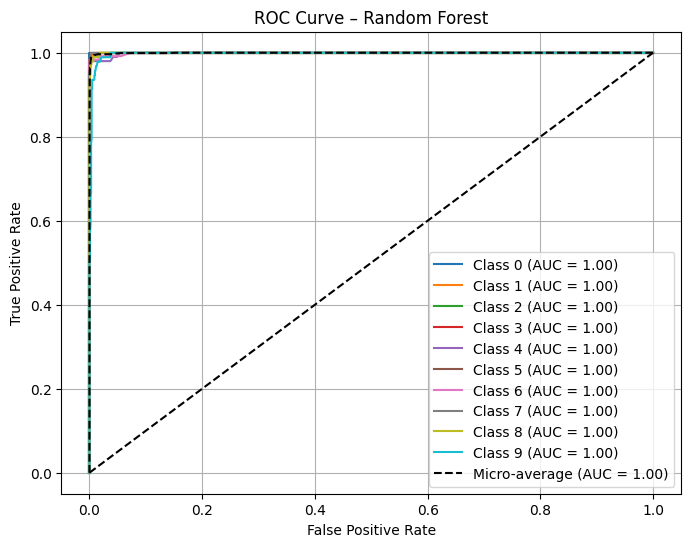

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- Fit the Random Forest with probability estimates ---
rf_clf = RandomForestClassifier(n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42)
rf_clf.fit(X_train, y_train)

# --- Predict class probabilities ---
y_score = rf_clf.predict_proba(X_test)

# --- Binarize the true labels ---
# use the same class order as the classifier
y_test_bin = label_binarize(y_test, classes=rf_clf.classes_)
n_classes = y_test_bin.shape[1]

# --- Plot ROC for each class ---
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {rf_clf.classes_[i]} (AUC = {roc_auc:.2f})")

# --- Micro-average ROC ---
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", color="black",
         label=f"Micro-average (AUC = {roc_auc_micro:.2f})")

# --- Plot settings ---
plt.plot([0, 1], [0, 1], 'k--')  # diagonal (chance)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ***Area Under The Curve(AUC) - Random Forest***

In [ ]:
from sklearn.metrics import roc_auc_score

# y_test_bin must be shape (n_samples, n_classes)
# y_score    must be shape (n_samples, n_classes)
# and the columns must correspond to the same class order as your classifier

roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

print(f"Macro-average AUC: {roc_auc_macro:.3f}")
print(f"Micro-average AUC: {roc_auc_micro:.3f}")


Macro-average AUC: 1.000
Micro-average AUC: 1.000


# ***After PCA(Principal Component Analysis) - Random Forest***

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- Scale ---
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# --- PCA (reduce to 10 components) ---
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# --- Random Forest ---
rf_clf = RandomForestClassifier(n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42)
rf_clf.fit(X_train_pca, y_train)

# --- Predict & Evaluate ---
y_pred = rf_clf.predict(X_test_pca)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 0.9261565836298933
Confusion matrix:
 [[106   0   0   0   1   0   0   0   1   0]
 [  0  99   0   0   0   0   1   2   0   0]
 [  0   1  95   0   1   0   0   5   4   1]
 [  0   0   0 101   0   3   0   1   4   9]
 [  0   1   0   0 108   1   1   2   1   3]
 [  0   0   0   0   1  89   0   0   4   3]
 [  1   1   0   0   0   0 121   0   0   0]
 [  0   1   0   0   0   0   0 122   0   1]
 [  0   5   0   2   0   3   0   2  93   0]
 [  0   2   0   5   0   3   0   0   6 107]]
Classification report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       108
           1       0.90      0.97      0.93       102
           2       1.00      0.89      0.94       107
           3       0.94      0.86      0.89       118
           4       0.97      0.92      0.95       117
           5       0.90      0.92      0.91        97
           6       0.98      0.98      0.98       123
           7       0.91      0.98      0.95       124
          